# EDA

In [8]:
import bvhio

bvh_path = "../data/002/02_01.bvh"
root = bvhio.readAsHierarchy(bvh_path)

# inspect skeleton structure
root.printTree()

Hips
+- LHipJoint
|  +- LeftUpLeg
|     +- LeftLeg
|        +- LeftFoot
|           +- LeftToeBase
+- RHipJoint
|  +- RightUpLeg
|     +- RightLeg
|        +- RightFoot
|           +- RightToeBase
+- LowerBack
   +- Spine
      +- Spine1
         +- Neck
         |  +- Neck1
         |     +- Head
         +- LeftShoulder
         |  +- LeftArm
         |     +- LeftForeArm
         |        +- LeftHand
         |           +- LeftFingerBase
         |           |  +- LeftHandIndex1
         |           +- LThumb
         +- RightShoulder
            +- RightArm
               +- RightForeArm
                  +- RightHand
                     +- RightFingerBase
                     |  +- RightHandIndex1
                     +- RThumb


(2646, 15, 3)
[[10.07734    -0.71228284 25.092813  ]
 [10.04305    -0.7486024  23.529621  ]
 [10.0061     -0.2602     17.8631    ]
 [ 6.5379     -0.78669    22.741901  ]
 [ 1.560327   -0.7866899  22.042349  ]
 [-1.7712419  -0.7866898  21.574127  ]
 [13.57797    -0.63416994 22.88632   ]
 [18.395754   -0.63417    22.209225  ]
 [21.71864    -0.63417    21.742224  ]
 [ 8.395399    0.36456007 16.06028   ]
 [ 8.52782     0.36456034  8.474094  ]
 [ 8.653749    0.3645609   1.2598143 ]
 [11.662839    0.36456957 16.06028   ]
 [11.530308    0.36456957  8.467721  ]
 [11.4031315   0.3645696   1.1816587 ]]
[[ 9.834528   -0.30629465 25.122751  ]
 [10.038015   -0.6505515  23.61075   ]
 [10.3115     -0.9184     17.9339    ]
 [ 6.7753687  -2.0733066  22.653486  ]
 [ 5.769721   -3.749146   18.02252   ]
 [ 6.3711457  -0.8496785  16.425657  ]
 [13.368792    0.35298777 23.150045  ]
 [13.562537   -0.52068573 18.367926  ]
 [13.613763    0.71994656 15.250577  ]
 [ 8.581893   -0.6830907  16.148422  ]
 [ 8.24132

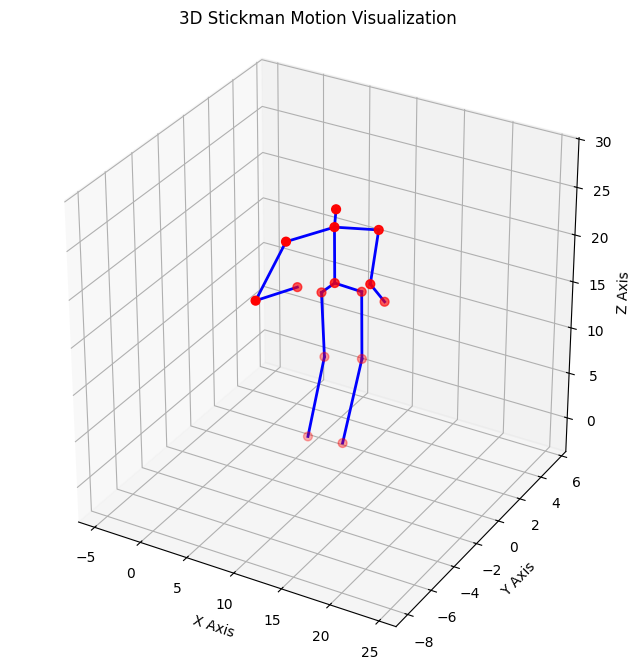

In [10]:
import sys
sys.path.append("..")

import importlib
import data_loader, utils
importlib.reload(data_loader)
importlib.reload(utils)

from data_loader import load_bvh_as_tensor
from utils import animate_skeleton_3d

tensor = load_bvh_as_tensor("../data/002/02_10.bvh")
print(tensor.shape)       
print(tensor[0])         
print(tensor[50])         

anim = animate_skeleton_3d(tensor[:48], output_filename="test_gifs/test_walk.gif")

# Select walk data

In [16]:
import pandas as pd

df = pd.read_excel("../cmu-mocap-index-spreadsheet.xls", header=None, skiprows=7)
df.columns = ["motion_id", "description", "subject"]
df = df.dropna(subset=["motion_id"])

walk_files = df[df["description"].str.contains("walk", case=False, na=False)]
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
print(walk_files[["motion_id", "description"]].to_string())
print("Walk files found:", len(walk_files))

     motion_id                                                                                                           description
20       02_01                                                                                                                  walk
21       02_02                                                                                                                  walk
31       03_01                                                                                                walk on uneven terrain
32       03_02                                                                                                walk on uneven terrain
33       03_03                                                                                                walk on uneven terrain
34       03_04                                                                                                walk on uneven terrain
36       05_01                                                       

In [17]:
clean_walk_keywords = ["^walk$", "^walk forward$", "^slow walk$", "^brisk walk$", "^normal walk$"]
pattern = "|".join(clean_walk_keywords)

clean_walk = df[df["description"].str.match(pattern, case=False, na=False)]
print(f"Clean walk files: {len(clean_walk)}")
print(clean_walk[["motion_id", "description"]].to_string())

Clean walk files: 112
     motion_id   description
20       02_01          walk
21       02_02          walk
36       05_01          walk
57       06_01          walk
73       07_01          walk
74       07_02          walk
75       07_03          walk
76       07_04     slow walk
77       07_05     slow walk
78       07_06          walk
79       07_07          walk
80       07_08          walk
81       07_09          walk
82       07_10          walk
83       07_11          walk
84       07_12    brisk walk
86       08_01          walk
87       08_02          walk
88       08_03          walk
89       08_04     slow walk
91       08_06          walk
93       08_08          walk
94       08_09          walk
95       08_10          walk
114      10_04          walk
120      12_01          walk
121      12_02          walk
122      12_03          walk
235      16_15          walk
236      16_16          walk
241      16_21          walk
242      16_22          walk
251      16_31       

In [18]:
import os

data_root = "../data"
available = []

for motion_id in clean_walk["motion_id"]:
    subject = motion_id.split("_")[0].zfill(3)
    filename = f"{motion_id}.bvh"
    path = os.path.join(data_root, subject, filename)
    if os.path.exists(path):
        available.append(path)

print(f"Available locally: {len(available)} / {len(clean_walk)}")

Available locally: 112 / 112


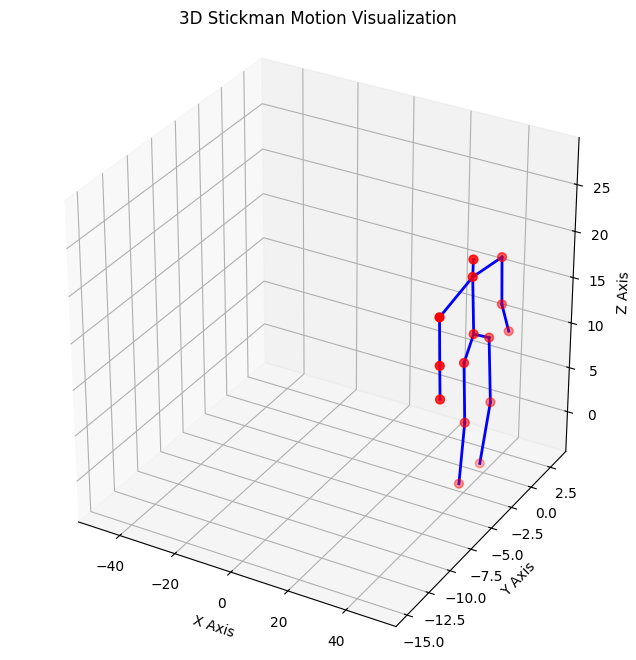

Saved: test_gifs/eda/normal_walk_136_23.gif


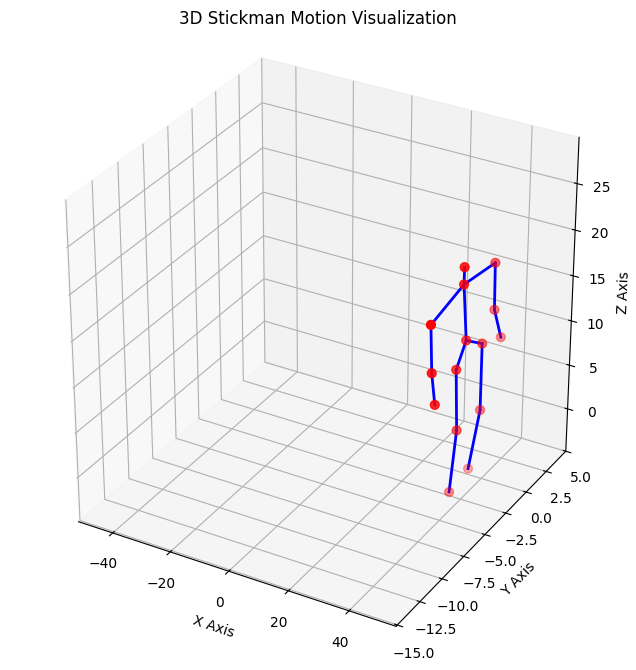

Saved: test_gifs/eda/normal_walk_136_21.gif


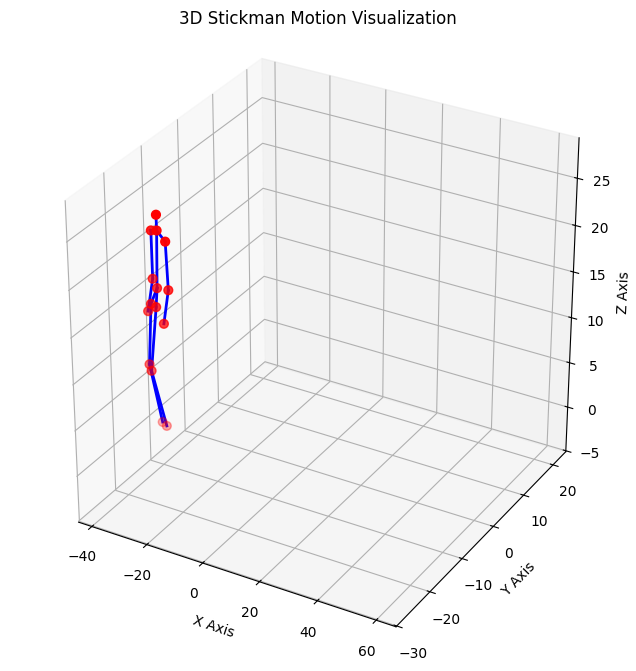

Saved: test_gifs/eda/normal_walk_137_29.gif


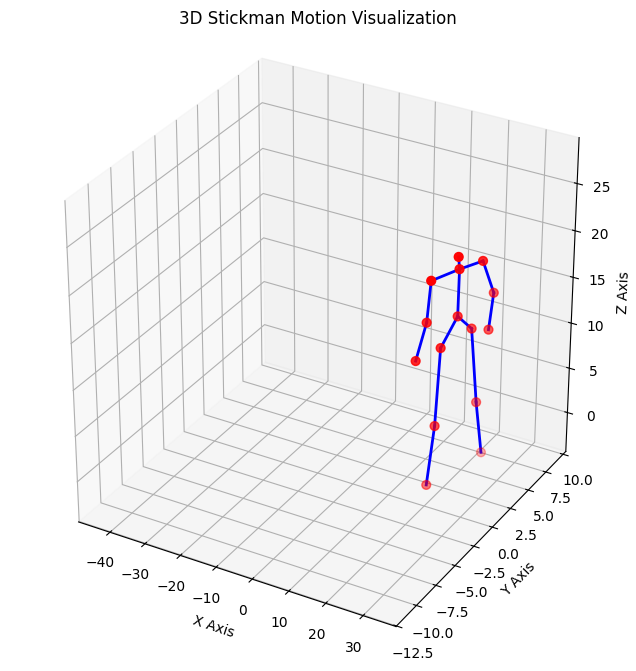

Saved: test_gifs/eda/walk_133_22.gif


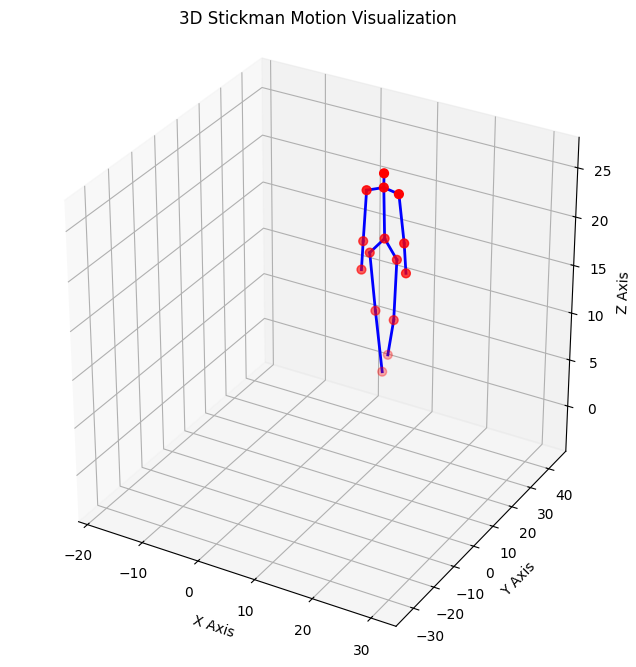

Saved: test_gifs/eda/walk_111_34.gif


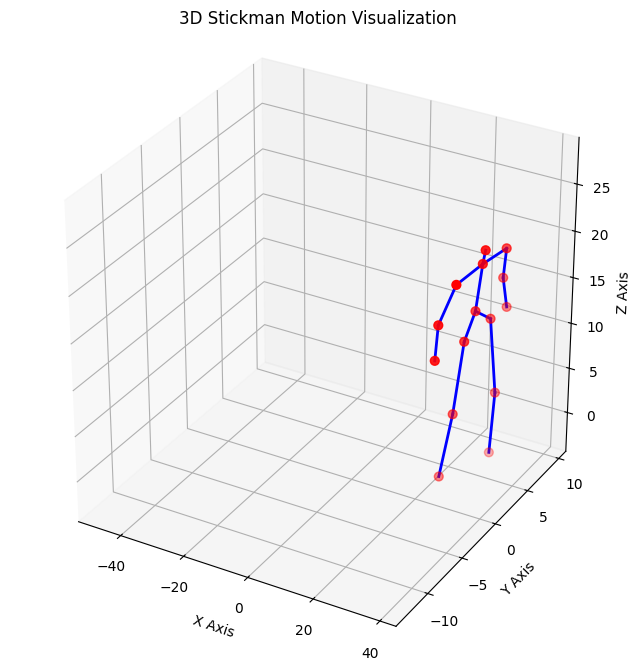

Saved: test_gifs/eda/walk_133_23.gif


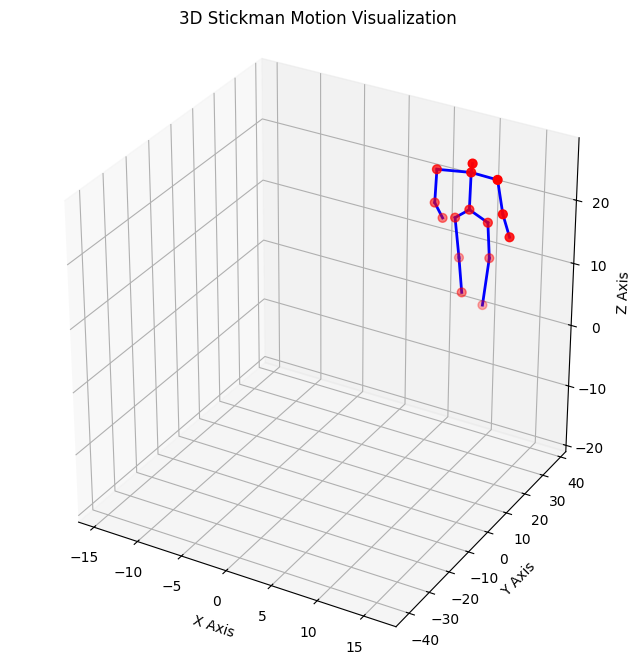

Saved: test_gifs/eda/brisk_walk_07_12.gif


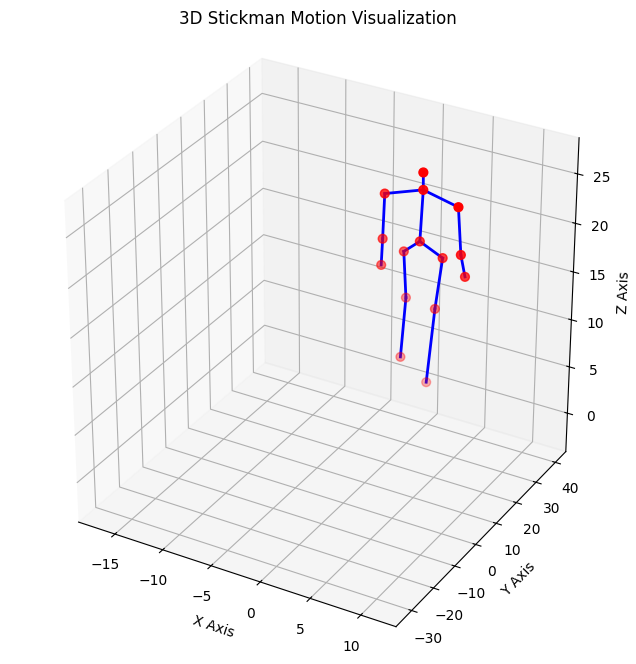

Saved: test_gifs/eda/slow_walk_37_01.gif


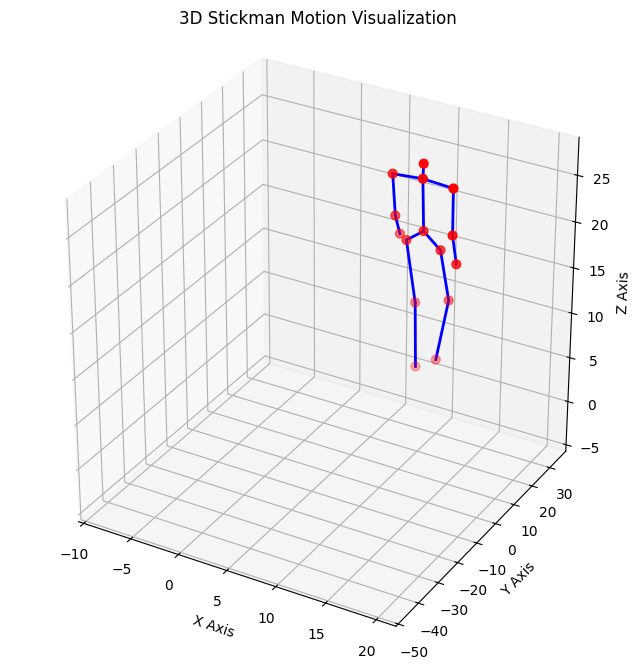

Saved: test_gifs/eda/slow_walk_08_04.gif


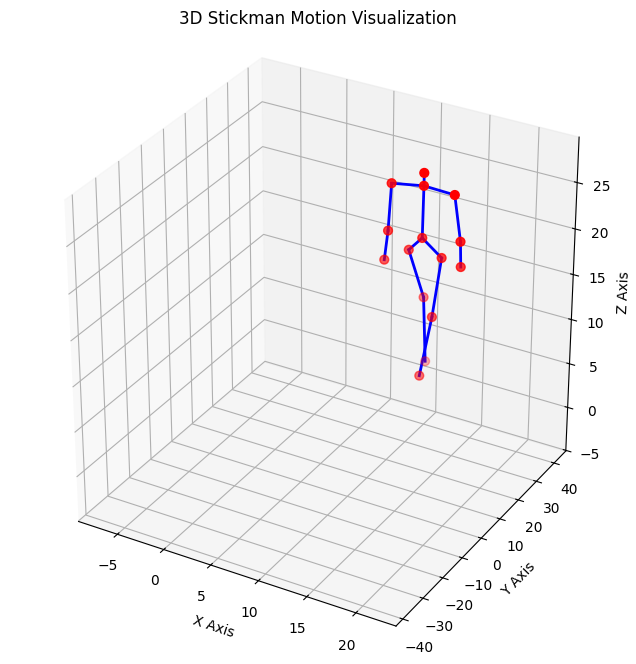

Saved: test_gifs/eda/slow_walk_07_05.gif


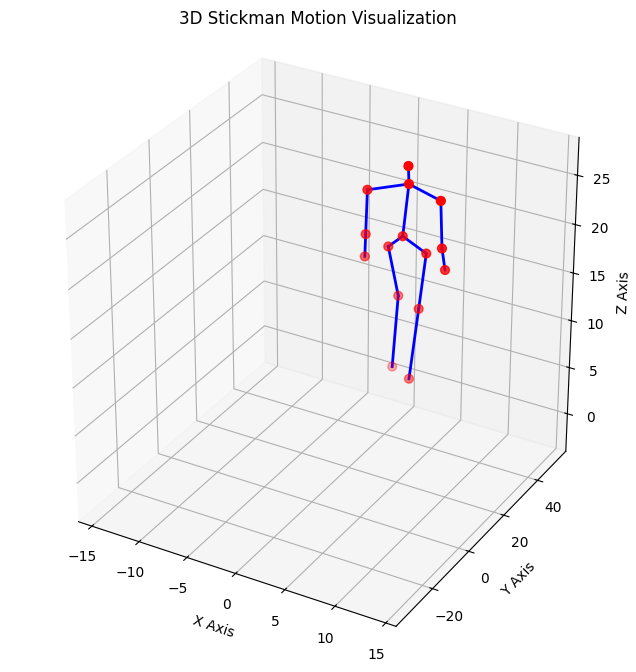

Saved: test_gifs/eda/walk_12_02.gif


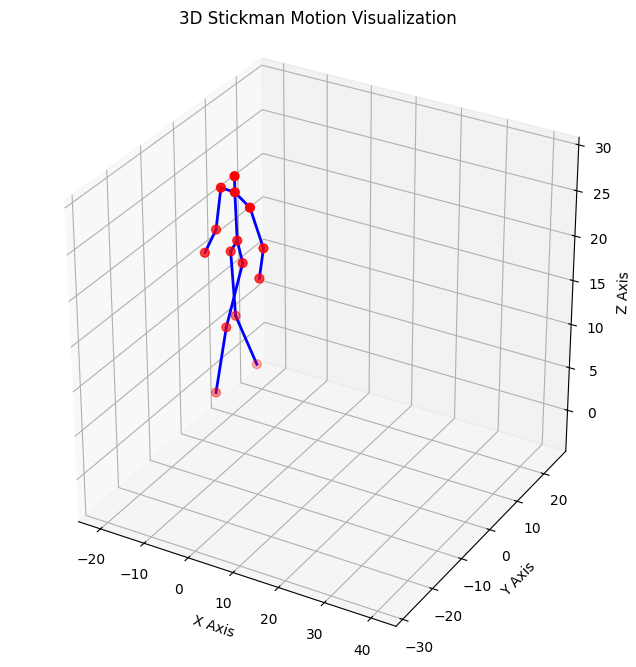

Saved: test_gifs/eda/walk_45_01.gif


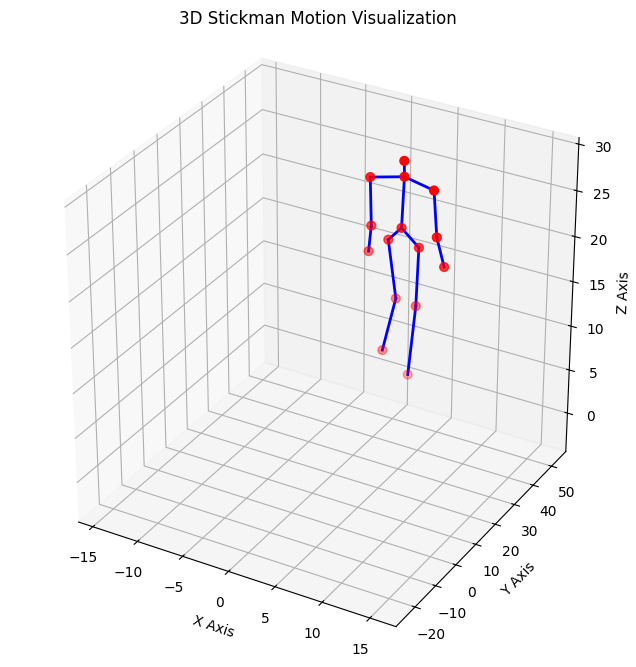

Saved: test_gifs/eda/walk_35_15.gif


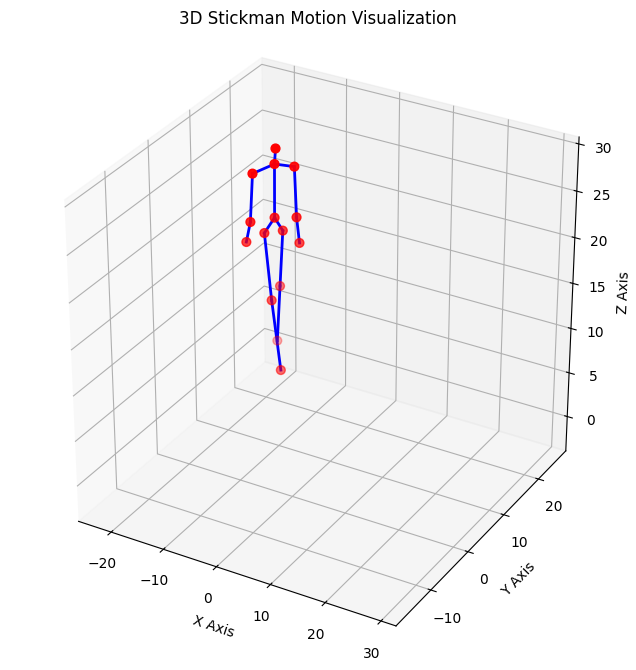

Saved: test_gifs/eda/walk_forward_69_02.gif


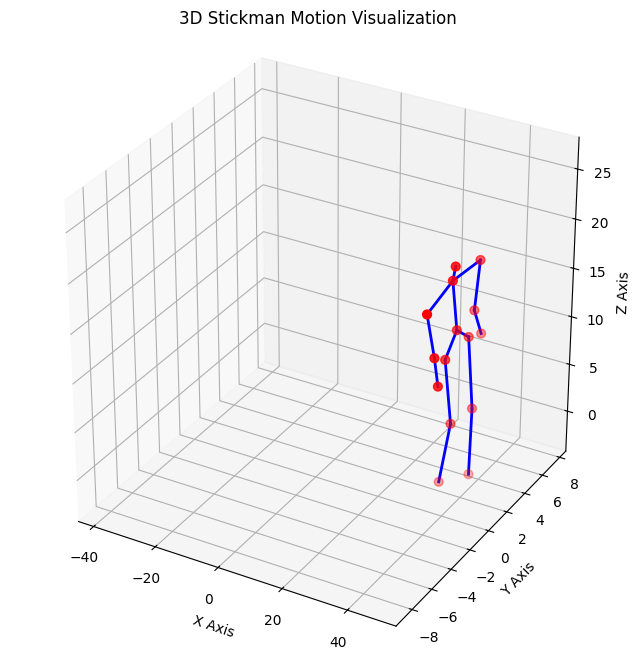

Saved: test_gifs/eda/walk_forward_81_02.gif


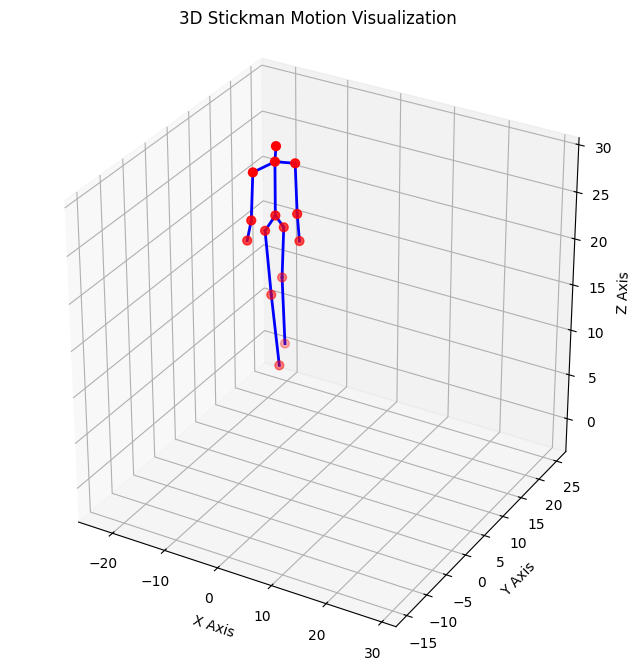

Saved: test_gifs/eda/walk_forward_69_01.gif


In [22]:
import os
import random
import sys
sys.path.append("..")

import importlib
import data_loader, utils
importlib.reload(data_loader)
importlib.reload(utils)

from data_loader import load_bvh_as_tensor
from utils import animate_skeleton_3d

OUTPUT_DIR = "test_gifs/eda"

os.makedirs(OUTPUT_DIR, exist_ok=True)

groups = clean_walk.groupby("description")

for desc, group in groups:
    paths = []
    for motion_id in group["motion_id"]:
        subject = motion_id.split("_")[0].zfill(3)
        path = f"../data/{subject}/{motion_id}.bvh"
        if os.path.exists(path):
            paths.append((motion_id, path))
    
    sampled = random.sample(paths, min(3, len(paths)))
    safe_desc = desc.lower().replace(" ", "_")
    
    for motion_id, path in sampled:
        tensor = load_bvh_as_tensor(path)
        filename = f"{OUTPUT_DIR}/{safe_desc}_{motion_id}.gif"
        anim = animate_skeleton_3d(tensor, output_filename=filename)
        print(f"Saved: {filename}")

In [23]:
import os
import shutil

OUTPUT_DIR = "selected_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for _, row in clean_walk.iterrows():
    motion_id = row["motion_id"]          # e.g. "07_04"
    description = row["description"]      # e.g. "slow walk"
    
    subject = motion_id.split("_")[0].zfill(3)
    src_path = f"../data/{subject}/{motion_id}.bvh"
    
    if not os.path.exists(src_path):
        print(f"Missing: {src_path}")
        continue
    
    desc_slug = description.strip().lower().replace(" ", "_")
    subject_part = motion_id.split("_")[0].zfill(3)
    take_part = motion_id.split("_")[1].zfill(3)
    new_name = f"{desc_slug}_{subject_part}_{take_part}.bvh"
    
    dst_path = os.path.join(OUTPUT_DIR, new_name)
    shutil.copy2(src_path, dst_path)
    print(f"Copied: {new_name}")

print(f"\nDone: {len(os.listdir(OUTPUT_DIR))} files in {OUTPUT_DIR}/")

Copied: walk_002_001.bvh
Copied: walk_002_002.bvh
Copied: walk_005_001.bvh
Copied: walk_006_001.bvh
Copied: walk_007_001.bvh
Copied: walk_007_002.bvh
Copied: walk_007_003.bvh
Copied: slow_walk_007_004.bvh
Copied: slow_walk_007_005.bvh
Copied: walk_007_006.bvh
Copied: walk_007_007.bvh
Copied: walk_007_008.bvh
Copied: walk_007_009.bvh
Copied: walk_007_010.bvh
Copied: walk_007_011.bvh
Copied: brisk_walk_007_012.bvh
Copied: walk_008_001.bvh
Copied: walk_008_002.bvh
Copied: walk_008_003.bvh
Copied: slow_walk_008_004.bvh
Copied: walk_008_006.bvh
Copied: walk_008_008.bvh
Copied: walk_008_009.bvh
Copied: walk_008_010.bvh
Copied: walk_010_004.bvh
Copied: walk_012_001.bvh
Copied: walk_012_002.bvh
Copied: walk_012_003.bvh
Copied: walk_016_015.bvh
Copied: walk_016_016.bvh
Copied: walk_016_021.bvh
Copied: walk_016_022.bvh
Copied: walk_016_031.bvh
Copied: walk_016_032.bvh
Copied: walk_016_047.bvh
Copied: walk_016_058.bvh
Copied: walk_026_001.bvh
Copied: walk_027_001.bvh
Copied: walk_029_001.bvh
Copi

# Select jump data

In [24]:
import pandas as pd
import os
import shutil

df = pd.read_excel("../cmu-mocap-index-spreadsheet.xls", header=None, skiprows=7)
df.columns = ["motion_id", "description", "subject"]
df = df.dropna(subset=["motion_id"])

jump_files = df[df["description"].str.contains("jump", case=False, na=False)]
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
print(jump_files[["motion_id", "description"]].to_string())
print("Jump files found:", len(jump_files))

     motion_id                                                                                                description
5        01_01                                                                    playground - forward jumps, turn around
11       01_07                                                            playground - climb, sit, dangle legs, jump down
15       01_11                                                             playground - climb, hang, lean over, jump down
17       01_13                                                                    playground - climb, go under, jump down
18       01_14                                               playground - climb, jump down, dangle, legs push off against
23       02_04                                                                                              jump, balance
134      13_10                                                                         jump up to grab, reach for, tiptoe
135      13_11          

In [29]:
clean_jump_keywords = [
    "^jump$",
    "^forward jump$",
    "^high jump$",
    "^jump forward$",
    "^jumpforward$",
    "^long jump forward$",
    # "^run jump$",
    # "^jump turn$",
    # "^jumpturn$",
]

In [30]:
import os

pattern = "|".join(clean_jump_keywords)
clean_jump = df[df["description"].str.match(pattern, case=False, na=False)]
print(f"Clean jump files: {len(clean_jump)}")
print(clean_jump[["motion_id", "description"]].to_string())

available_jump = []
for motion_id in clean_jump["motion_id"]:
    subject = motion_id.split("_")[0].zfill(3)
    path = f"../data/{subject}/{motion_id}.bvh"
    if os.path.exists(path):
        available_jump.append(path)

print(f"Available locally: {len(available_jump)} / {len(clean_jump)}")

Clean jump files: 61
     motion_id        description
135      13_11       forward jump
137      13_13       forward jump
143      13_19       forward jump
156      13_32       forward jump
163      13_39               jump
164      13_40               jump
165      13_41               jump
166      13_42               jump
221      16_01               jump
222      16_02               jump
223      16_03          high jump
224      16_04          high jump
225      16_05       forward jump
226      16_06       forward jump
227      16_07       forward jump
229      16_09       forward jump
230      16_10       forward jump
1327     83_42  long jump forward
1328     83_43  long jump forward
1332     83_47  long jump forward
1335     83_50  long jump forward
1487     91_39        JumpForward
1488     91_40        JumpForward
1489     91_41        JumpForward
1490     91_42        JumpForward
1493     91_45        JumpForward
1677    105_39        JumpForward
1678    105_40        JumpF

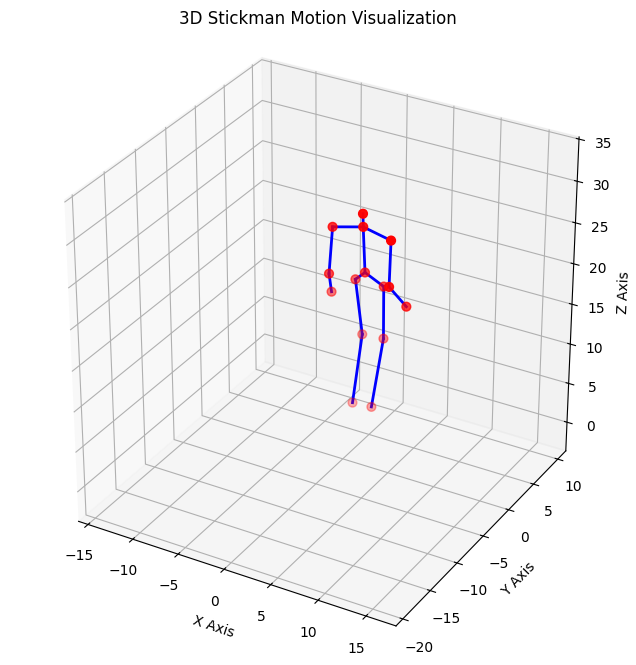

Saved: test_gifs/eda/jump/forward_jump_16_05.gif


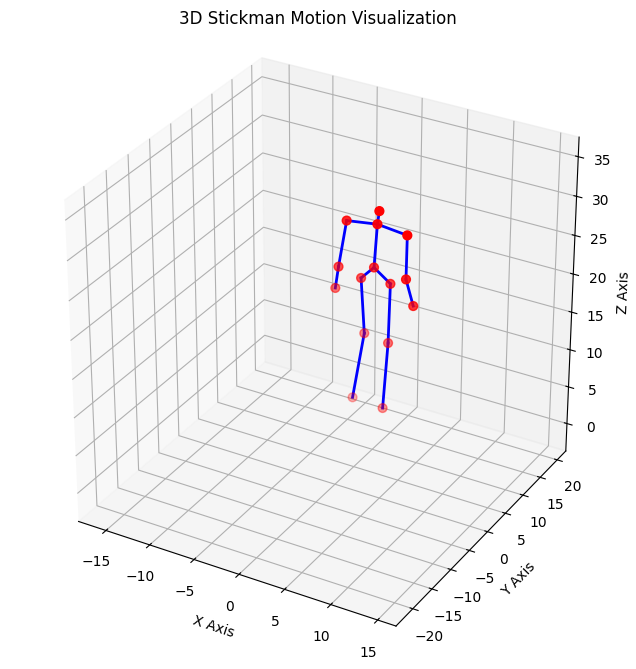

Saved: test_gifs/eda/jump/forward_jump_13_19.gif


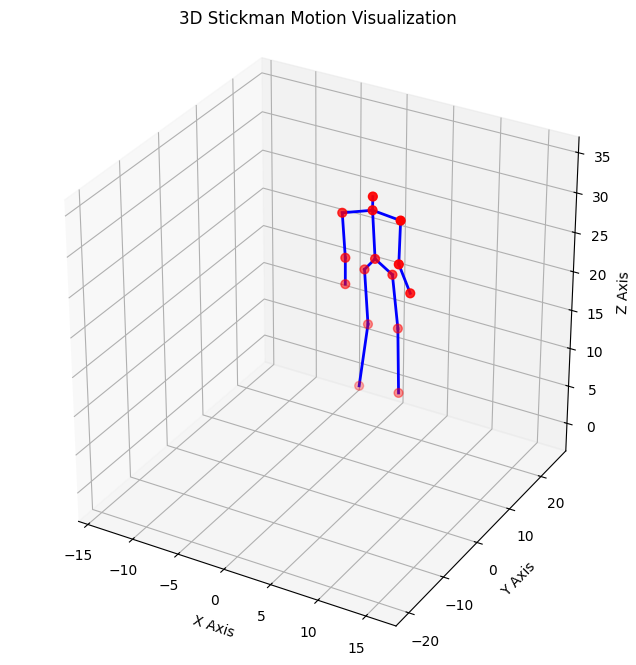

Saved: test_gifs/eda/jump/forward_jump_16_10.gif


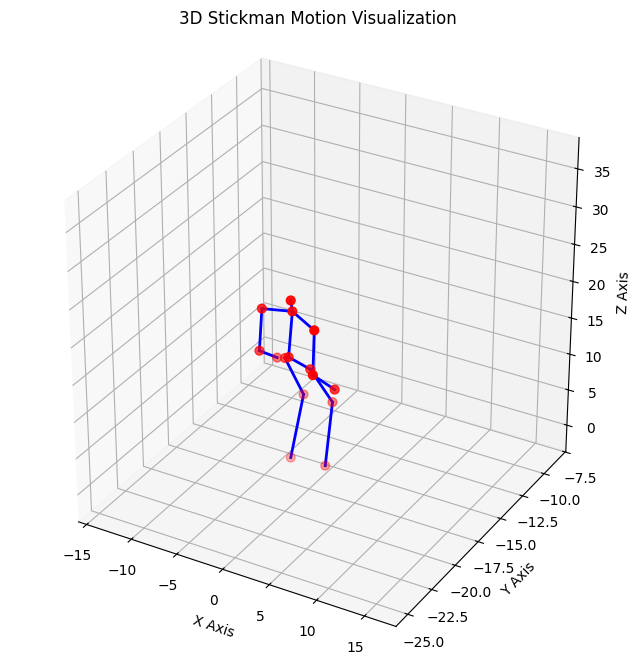

Saved: test_gifs/eda/jump/high_jump_16_03.gif


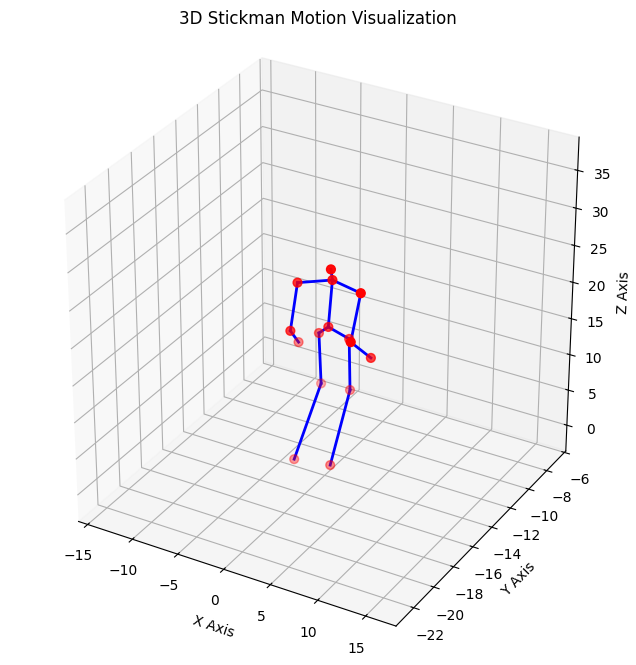

Saved: test_gifs/eda/jump/high_jump_16_04.gif


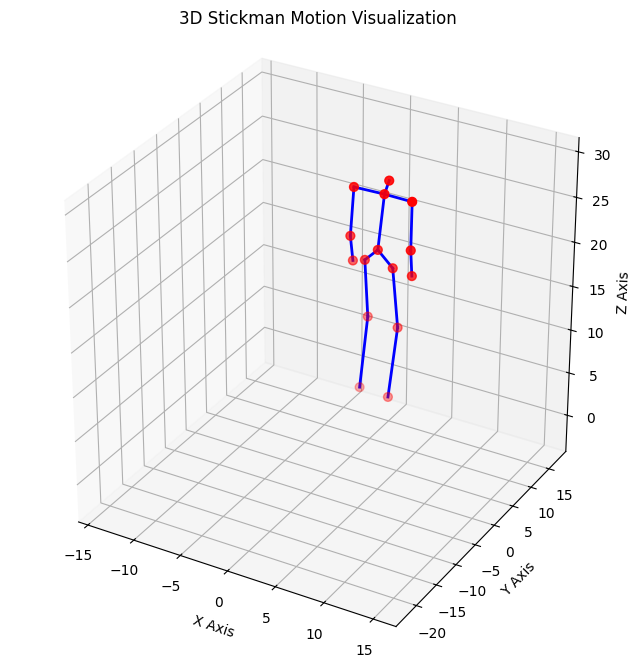

Saved: test_gifs/eda/jump/jump_118_27.gif


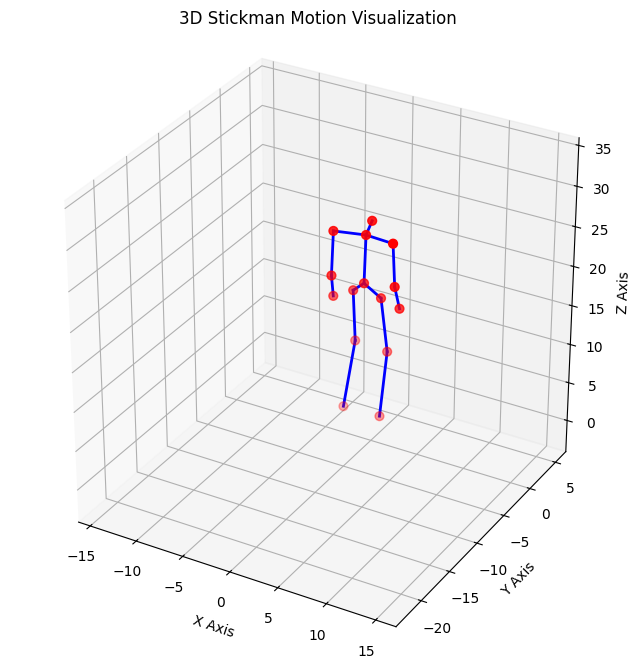

Saved: test_gifs/eda/jump/jump_118_11.gif


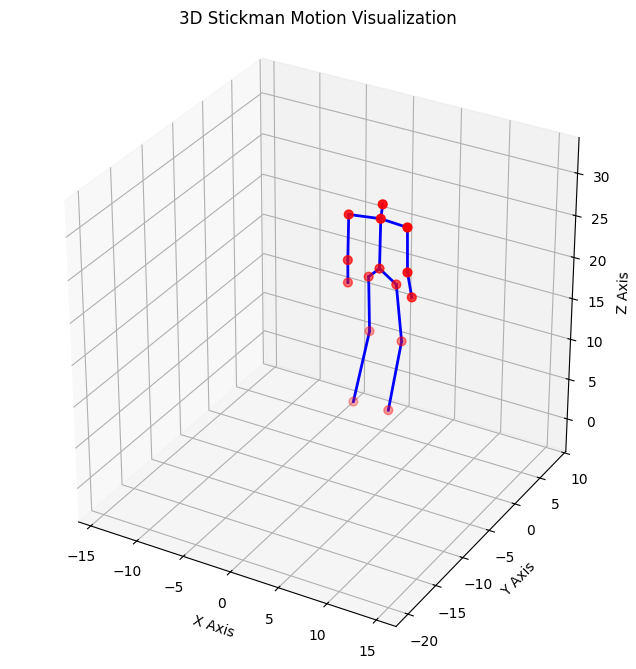

Saved: test_gifs/eda/jump/jump_118_13.gif


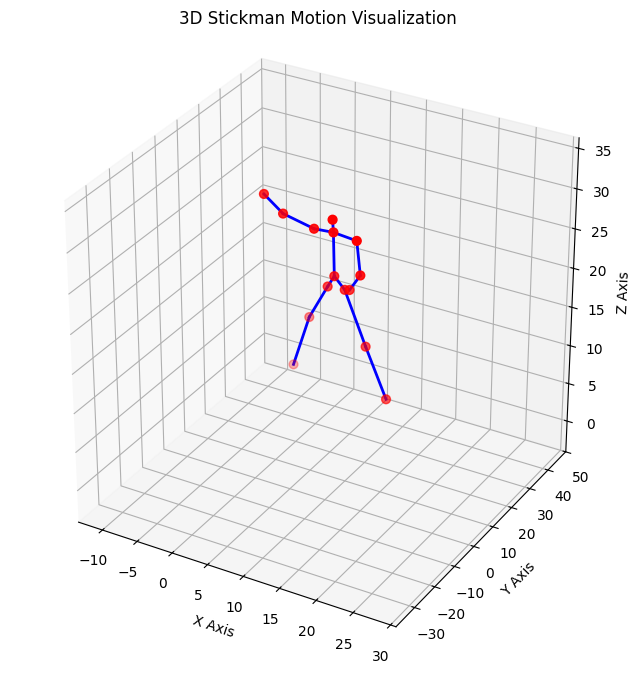

Saved: test_gifs/eda/jump/jump_stop_131_08.gif


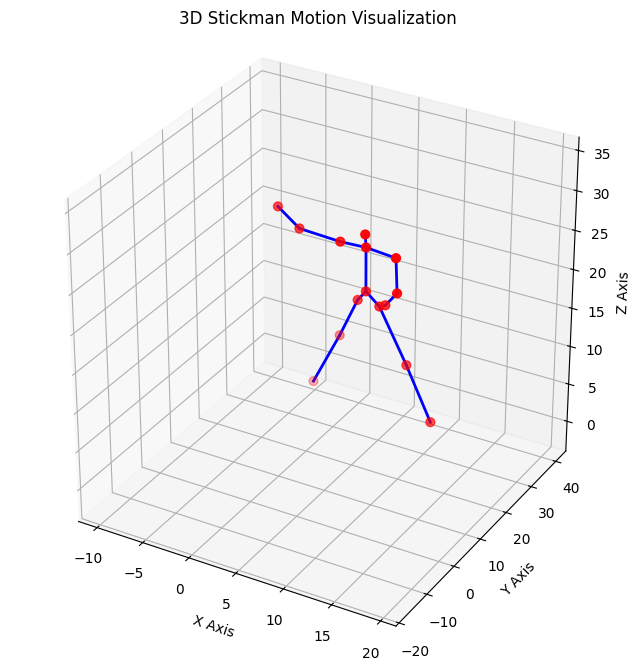

Saved: test_gifs/eda/jump/jump_stop_131_07.gif


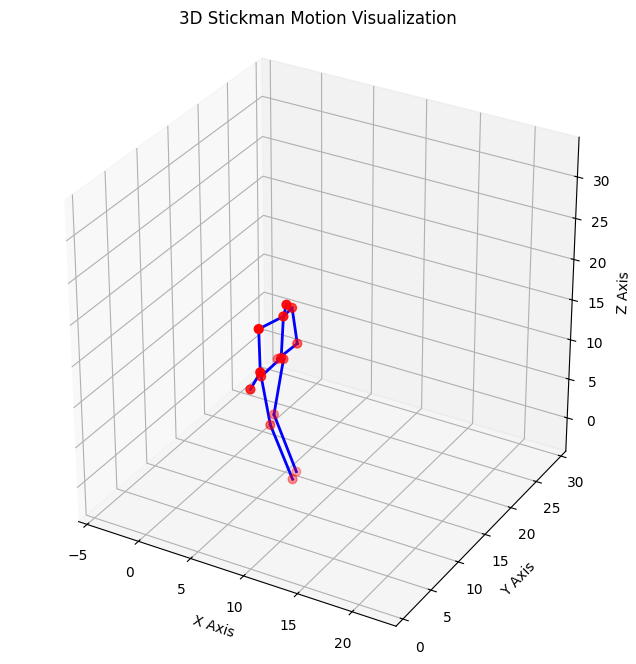

Saved: test_gifs/eda/jump/jump_turn_91_47.gif


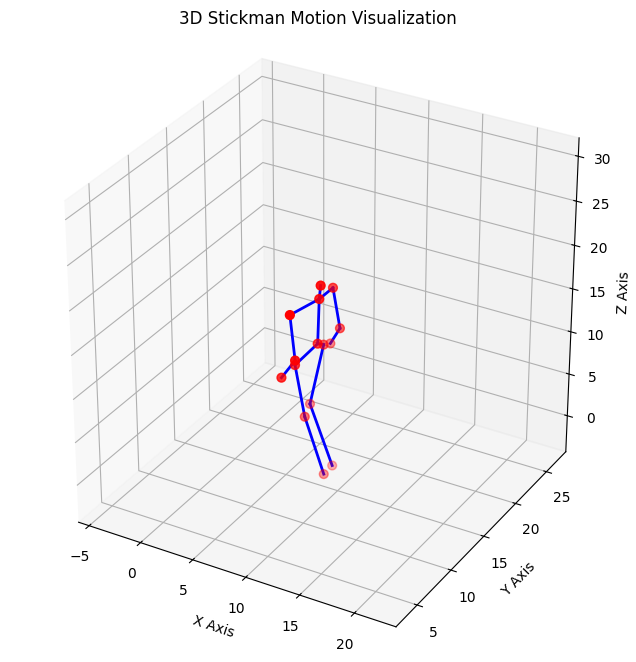

Saved: test_gifs/eda/jump/jump_turn_105_46.gif


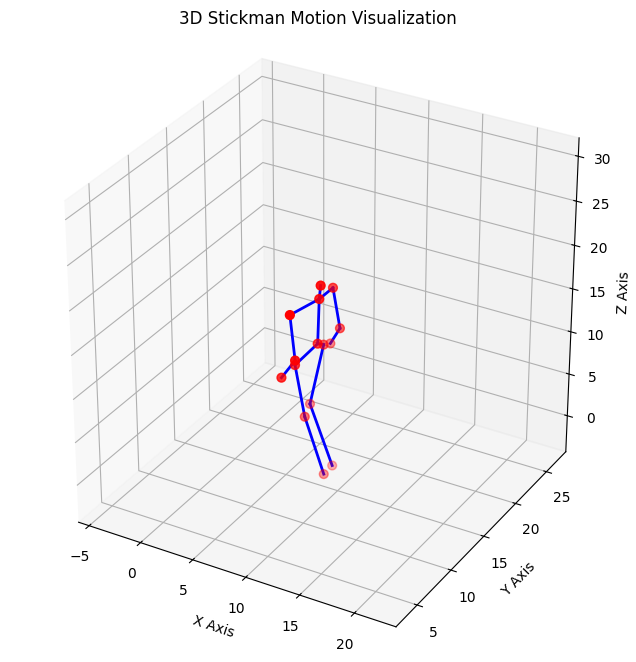

Saved: test_gifs/eda/jump/jump_turn_91_46.gif


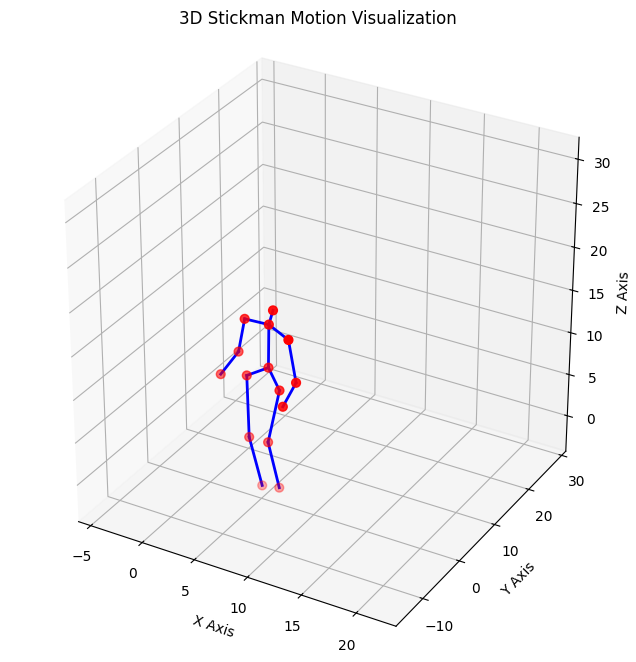

Saved: test_gifs/eda/jump/jumpforward_105_42.gif


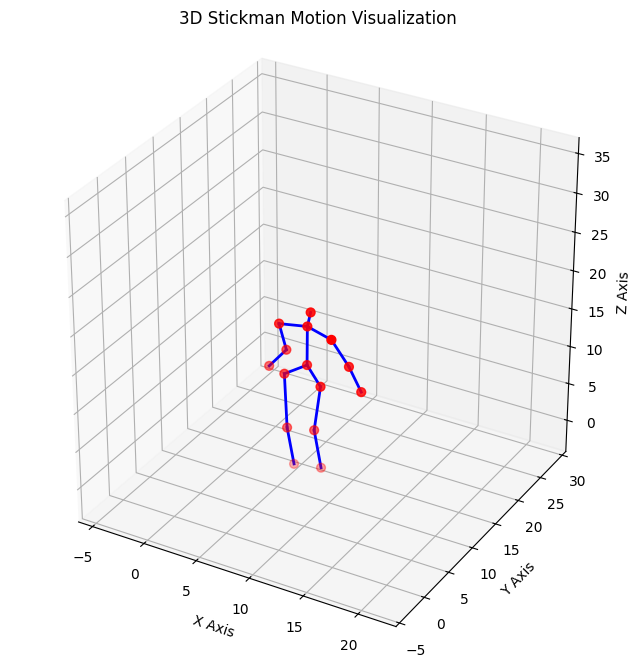

Saved: test_gifs/eda/jump/jumpforward_105_45.gif


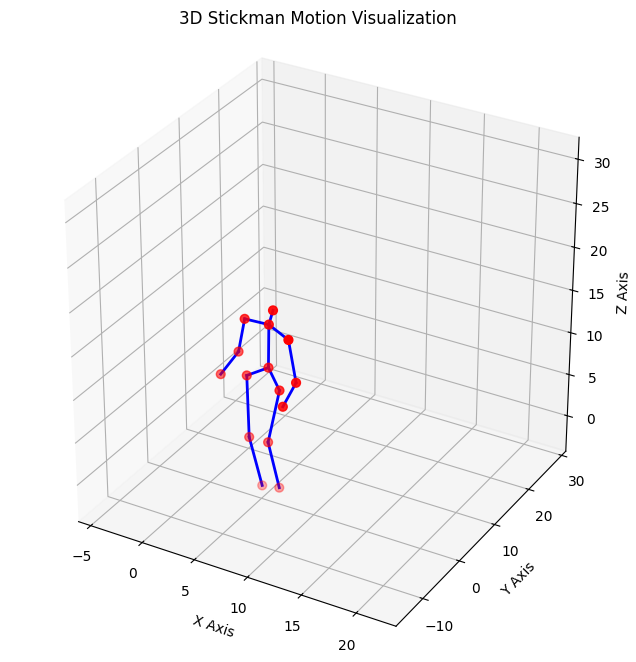

Saved: test_gifs/eda/jump/jumpforward_91_42.gif


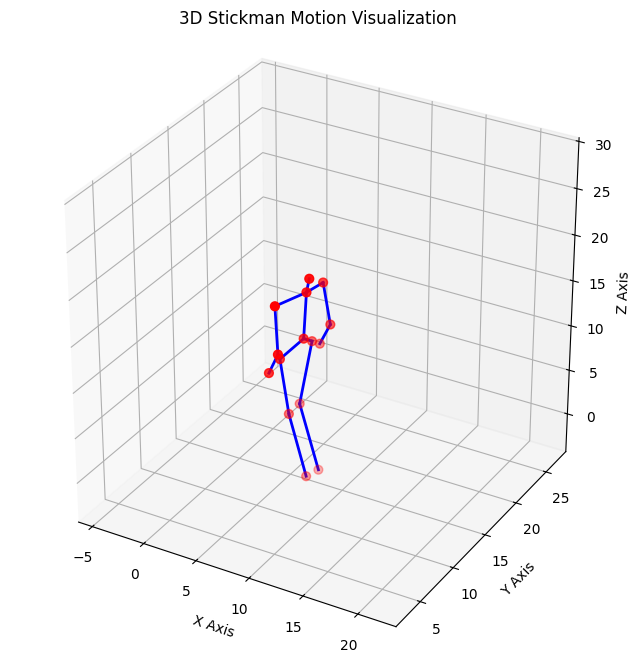

Saved: test_gifs/eda/jump/jumpturn_105_48.gif


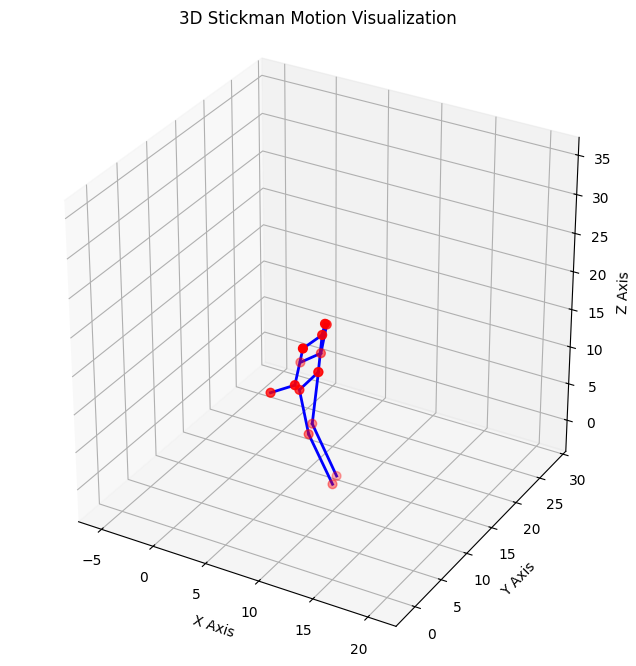

Saved: test_gifs/eda/jump/jumpturn_105_50.gif


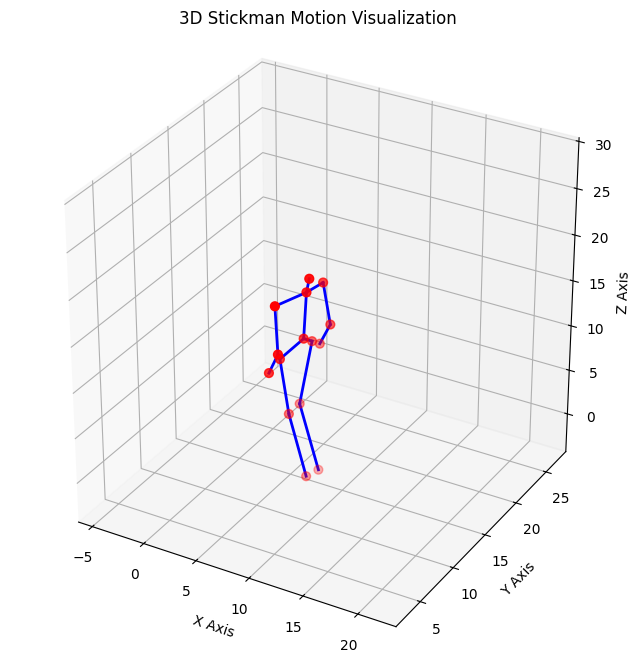

Saved: test_gifs/eda/jump/jumpturn_91_48.gif


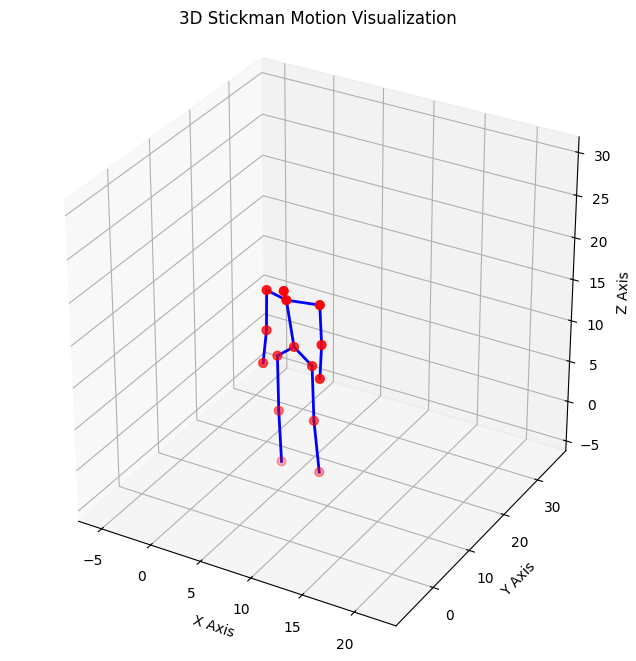

Saved: test_gifs/eda/jump/long_jump_forward_83_50.gif


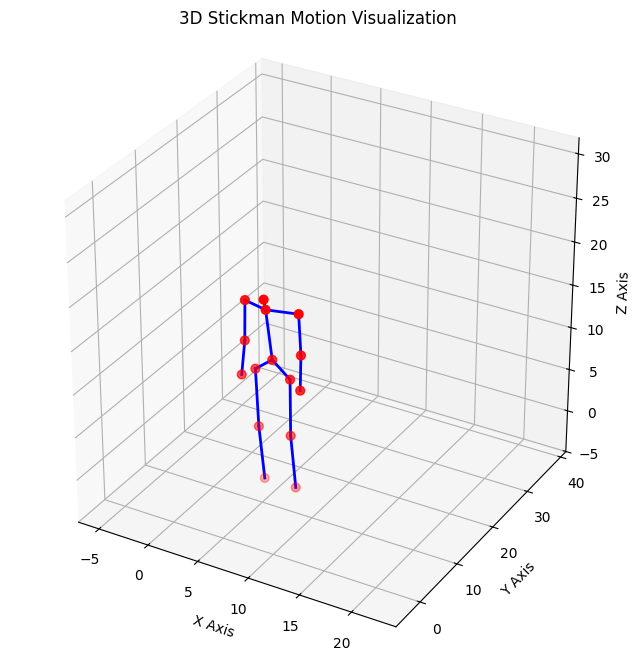

Saved: test_gifs/eda/jump/long_jump_forward_83_43.gif


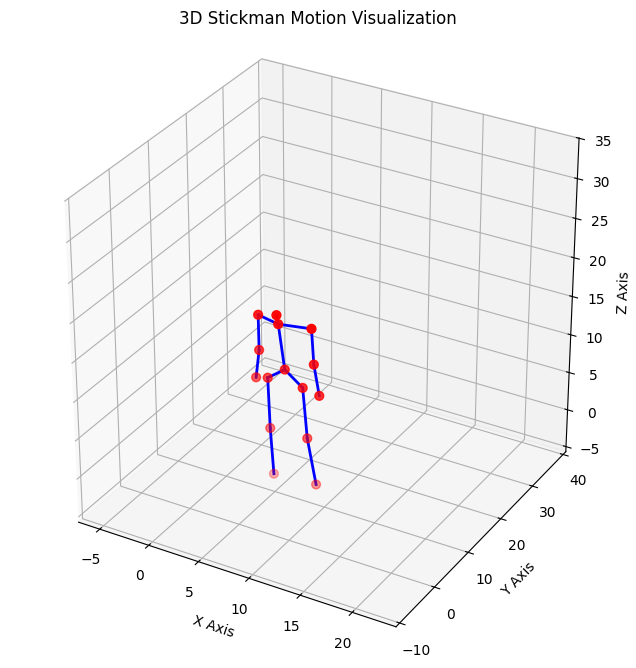

Saved: test_gifs/eda/jump/long_jump_forward_83_47.gif


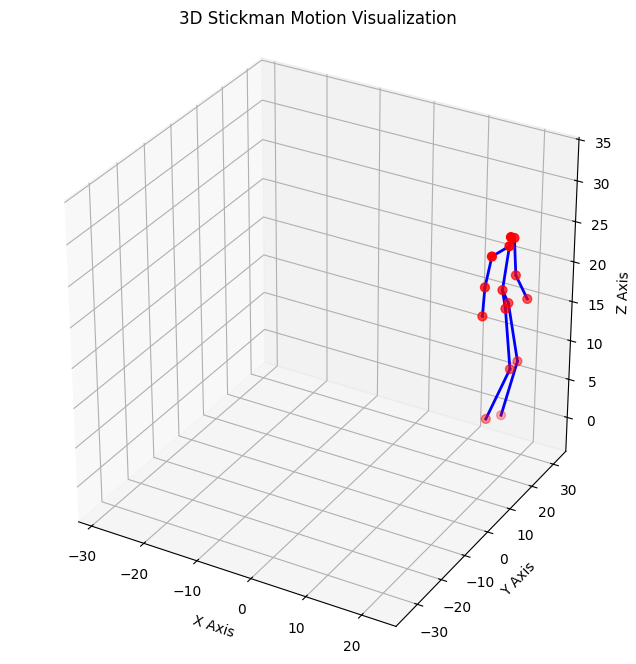

Saved: test_gifs/eda/jump/run_jump_75_02.gif


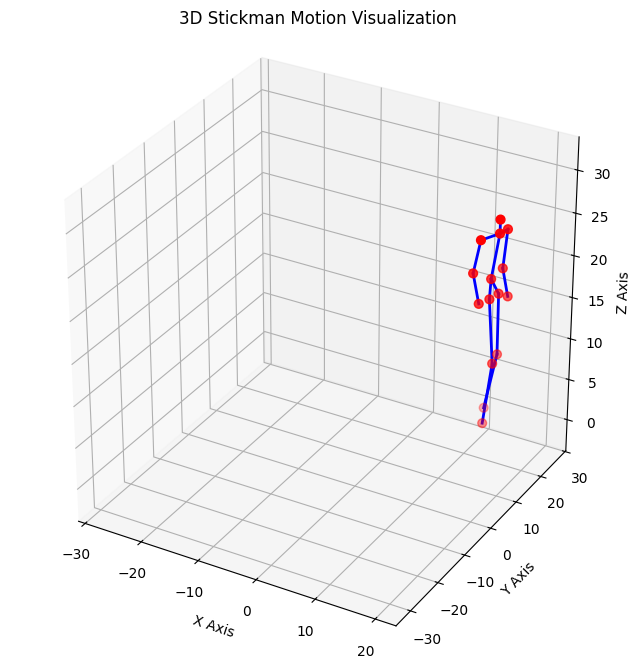

Saved: test_gifs/eda/jump/run_jump_75_01.gif


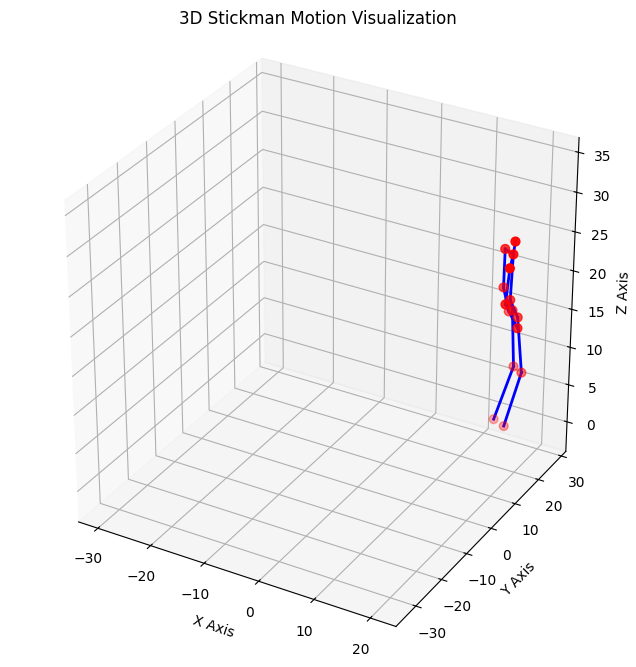

Saved: test_gifs/eda/jump/run_jump_75_03.gif


In [27]:
import os
import random
import sys
sys.path.append("..")

import importlib
import data_loader, utils
importlib.reload(data_loader)
importlib.reload(utils)

from data_loader import load_bvh_as_tensor
from utils import animate_skeleton_3d

OUTPUT_DIR = "test_gifs/eda/jump"
os.makedirs(OUTPUT_DIR, exist_ok=True)

clean_jump["description"] = clean_jump["description"].str.strip().str.lower()
groups = clean_jump.groupby("description")

for desc, group in groups:
    paths = []
    for motion_id in group["motion_id"]:
        subject = motion_id.split("_")[0].zfill(3)
        path = f"../data/{subject}/{motion_id}.bvh"
        if os.path.exists(path):
            paths.append((motion_id, path))

    sampled = random.sample(paths, min(3, len(paths)))
    safe_desc = desc.lower().replace(" ", "_")

    for motion_id, path in sampled:
        tensor = load_bvh_as_tensor(path)
        filename = f"{OUTPUT_DIR}/{safe_desc}_{motion_id}.gif"
        anim = animate_skeleton_3d(tensor, output_filename=filename)
        print(f"Saved: {filename}")

In [33]:
import os
import shutil

OUTPUT_DIR = "selected_data/jump"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for _, row in clean_jump.iterrows():
    motion_id = row["motion_id"]
    description = row["description"]

    subject = motion_id.split("_")[0].zfill(3)
    src_path = f"../data/{subject}/{motion_id}.bvh"

    if not os.path.exists(src_path):
        print(f"Missing: {src_path}")
        continue

    desc_slug = description.strip().lower().replace(" ", "_")
    subject_part = motion_id.split("_")[0].zfill(3)
    take_part = motion_id.split("_")[1].zfill(3)
    new_name = f"{desc_slug}_{subject_part}_{take_part}.bvh"

    shutil.copy2(src_path, os.path.join(OUTPUT_DIR, new_name))
    print(f"Copied: {new_name}")

print(f"\nDone: {len(os.listdir(OUTPUT_DIR))} files in {OUTPUT_DIR}/")

Copied: forward_jump_013_011.bvh
Copied: forward_jump_013_013.bvh
Copied: forward_jump_013_019.bvh
Copied: forward_jump_013_032.bvh
Copied: jump_013_039.bvh
Copied: jump_013_040.bvh
Copied: jump_013_041.bvh
Copied: jump_013_042.bvh
Copied: jump_016_001.bvh
Copied: jump_016_002.bvh
Copied: high_jump_016_003.bvh
Copied: high_jump_016_004.bvh
Copied: forward_jump_016_005.bvh
Copied: forward_jump_016_006.bvh
Copied: forward_jump_016_007.bvh
Copied: forward_jump_016_009.bvh
Copied: forward_jump_016_010.bvh
Copied: long_jump_forward_083_042.bvh
Copied: long_jump_forward_083_043.bvh
Copied: long_jump_forward_083_047.bvh
Copied: long_jump_forward_083_050.bvh
Copied: jumpforward_091_039.bvh
Copied: jumpforward_091_040.bvh
Copied: jumpforward_091_041.bvh
Copied: jumpforward_091_042.bvh
Copied: jumpforward_091_045.bvh
Copied: jumpforward_105_039.bvh
Copied: jumpforward_105_040.bvh
Copied: jumpforward_105_041.bvh
Copied: jumpforward_105_042.bvh
Copied: jumpforward_105_045.bvh
Copied: jump_118_001.

In [34]:
import os
from data_loader import load_bvh_as_tensor

for label in ["walk", "jump"]:
    folder = f"selected_data/{label}"
    lengths = []
    for fname in sorted(os.listdir(folder)):
        if fname.endswith(".bvh"):
            seq = load_bvh_as_tensor(os.path.join(folder, fname))
            lengths.append((fname, seq.shape[0]))
    lengths.sort(key=lambda x: x[1])
    print(f"\n=== {label.upper()} ===")
    print(f"min: {lengths[0]}, max: {lengths[-1]}")
    print(f"mean: {sum(l for _, l in lengths) / len(lengths):.0f}")
    print(f"median: {sorted(l for _, l in lengths)[len(lengths)//2]}")


=== WALK ===
min: ('brisk_walk_007_012.bvh', 264), max: ('walk_120_020.bvh', 10736)
mean: 690
median: 428

=== JUMP ===
min: ('forward_jump_016_005.bvh', 296), max: ('jump_118_030.bvh', 826)
mean: 544
median: 544


In [37]:
seq = load_bvh_as_tensor("selected_data/jump/high_jump_016_003.bvh")
pelvis = seq[:, 2, :]
diffs = np.linalg.norm(np.diff(pelvis, axis=0), axis=1)
print(f"T: {seq.shape[0]}")
print(f"min diff: {diffs.min():.6f}")
print(f"max diff: {diffs.max():.6f}")
print(f"mean diff: {diffs.mean():.6f}")
print(f"first 30 diffs: {diffs[:30]}")
print(f"last 30 diffs: {diffs[-30:]}")

T: 411
min diff: 0.000000
max diff: 0.467478
mean diff: 0.086402
first 30 diffs: [0.         0.00193182 0.00177225 0.00283993 0.00395673 0.004359
 0.00310117 0.00283541 0.0018186  0.0004569  0.00148651 0.00243898
 0.00283923 0.0036777  0.00124261 0.00377086 0.00197105 0.00054005
 0.00169894 0.00113701 0.00108252 0.00390908 0.00206146 0.00257689
 0.00343348 0.00245098 0.00359045 0.00212173 0.00332277 0.00195162]
last 30 diffs: [0.01922746 0.01443512 0.0122107  0.01788457 0.02084596 0.02365661
 0.0243785  0.01952219 0.01593699 0.01437024 0.01568683 0.01846806
 0.01867921 0.01851834 0.01916085 0.022672   0.02686458 0.02554898
 0.02352333 0.01877527 0.02002346 0.02601346 0.02623489 0.02582696
 0.02526171 0.02445864 0.02324376 0.02412786 0.0290667  0.0358706 ]


In [39]:
import numpy as np

seq = load_bvh_as_tensor("selected_data/jump/high_jump_016_003.bvh")
pelvis = seq[:, 2, :]
diffs = np.linalg.norm(np.diff(pelvis, axis=0), axis=1)
threshold = np.percentile(diffs, 20)
print(f"threshold (p20): {threshold:.6f}")
lead = next((i for i, d in enumerate(diffs) if d > threshold), 0)
trail = next((i for i, d in enumerate(reversed(diffs)) if d > threshold), 0)
print(f"lead: {lead}, trail: {trail}, total: {seq.shape[0]}, remaining: {seq.shape[0] - lead - trail}")

threshold (p20): 0.003575
lead: 4, trail: 0, total: 411, remaining: 407


In [40]:
for fname in ["selected_data/walk/walk_007_001.bvh", 
              "selected_data/jump/high_jump_016_003.bvh",
              "selected_data/jump/forward_jump_016_005.bvh"]:
    seq = load_bvh_as_tensor(fname)
    pelvis = seq[:, 2, :]
    diffs = np.linalg.norm(np.diff(pelvis, axis=0), axis=1)
    threshold = np.percentile(diffs, 20)
    lead = next((i for i, d in enumerate(diffs) if d > threshold), 0)
    trail = next((i for i, d in enumerate(reversed(diffs)) if d > threshold), 0)
    remaining = seq.shape[0] - lead - trail
    print(f"{os.path.basename(fname):<40} T={seq.shape[0]:>4}  lead={lead:>3}  trail={trail:>3}  remaining={remaining:>4}")

walk_007_001.bvh                         T= 317  lead=  1  trail=  0  remaining= 316
high_jump_016_003.bvh                    T= 411  lead=  4  trail=  0  remaining= 407
forward_jump_016_005.bvh                 T= 296  lead= 39  trail=  0  remaining= 257


In [42]:
import os
import numpy as np
from data_loader import load_bvh_as_tensor

DATA_ROOT = "selected_data"
OUT_ROOT = "trimmed_data"


def trim_sequence(seq: np.ndarray, percentile: int = 20) -> np.ndarray:
    pelvis = seq[:, 2, :]
    diffs = np.linalg.norm(np.diff(pelvis, axis=0), axis=1)
    threshold = np.percentile(diffs, percentile)
    lead = next((i for i, d in enumerate(diffs) if d > threshold), 0)
    trail = next((i for i, d in enumerate(reversed(diffs)) if d > threshold), 0)
    end = seq.shape[0] - trail if trail > 0 else seq.shape[0]
    return seq[lead:end]


for label in ["walk", "jump"]:
    in_folder = os.path.join(DATA_ROOT, label)
    out_folder = os.path.join(OUT_ROOT, label)
    os.makedirs(out_folder, exist_ok=True)

    for fname in sorted(os.listdir(in_folder)):
        if not fname.endswith(".bvh"):
            continue
        seq = load_bvh_as_tensor(os.path.join(in_folder, fname))
        trimmed = trim_sequence(seq)
        out_path = os.path.join(out_folder, fname.replace(".bvh", ".npy"))
        np.save(out_path, trimmed)
        print(f"{fname:<45} {seq.shape[0]:>5} -> {trimmed.shape[0]:>5}")

brisk_walk_007_012.bvh                          264 ->   262
normal_walk_136_020.bvh                         994 ->   993
normal_walk_136_021.bvh                         602 ->   481
normal_walk_136_022.bvh                         837 ->   820
normal_walk_136_023.bvh                         743 ->   594
normal_walk_136_024.bvh                        1076 ->   861
normal_walk_137_029.bvh                        1129 ->  1022
slow_walk_007_004.bvh                           450 ->   420
slow_walk_007_005.bvh                           518 ->   517
slow_walk_008_004.bvh                           485 ->   481
slow_walk_037_001.bvh                           512 ->   507
walk_002_001.bvh                                344 ->   343
walk_002_002.bvh                                299 ->   294
walk_005_001.bvh                                599 ->   579
walk_006_001.bvh                                495 ->   485
walk_007_001.bvh                                317 ->   316
walk_007_002.bvh        

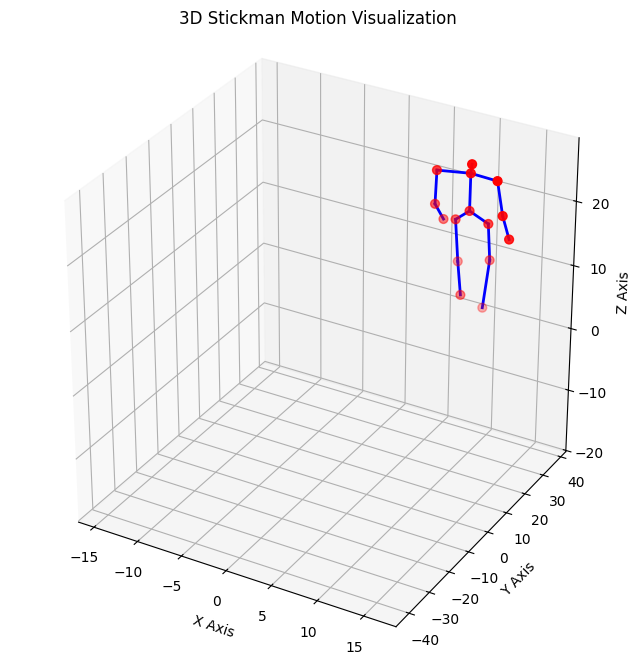

saved: test_gifs/trimmed\walk_brisk_walk_007_012.gif  T=262


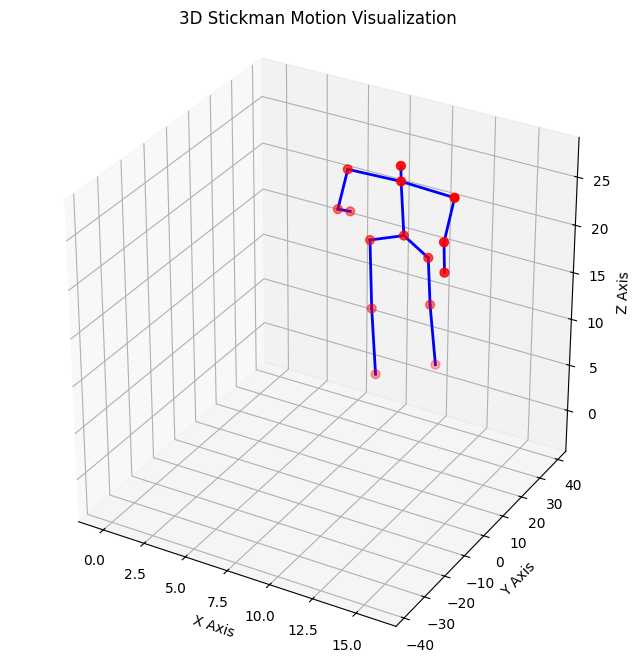

saved: test_gifs/trimmed\walk_walk_008_010.gif  T=275


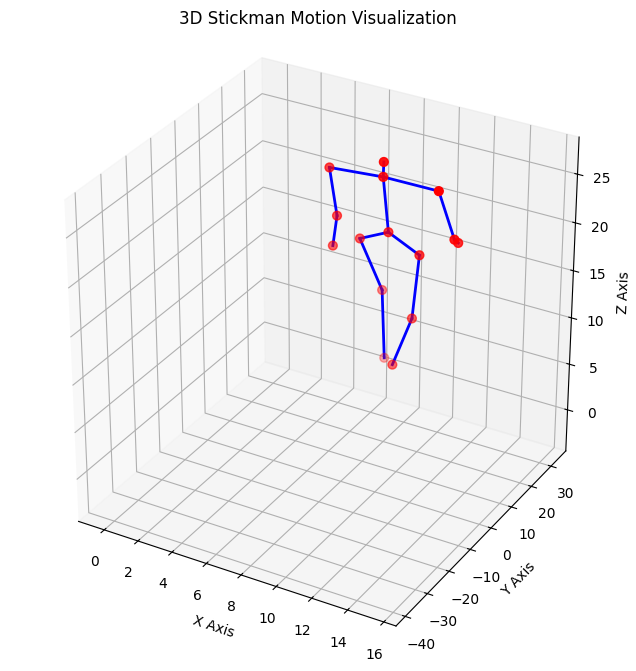

saved: test_gifs/trimmed\walk_walk_008_001.gif  T=277


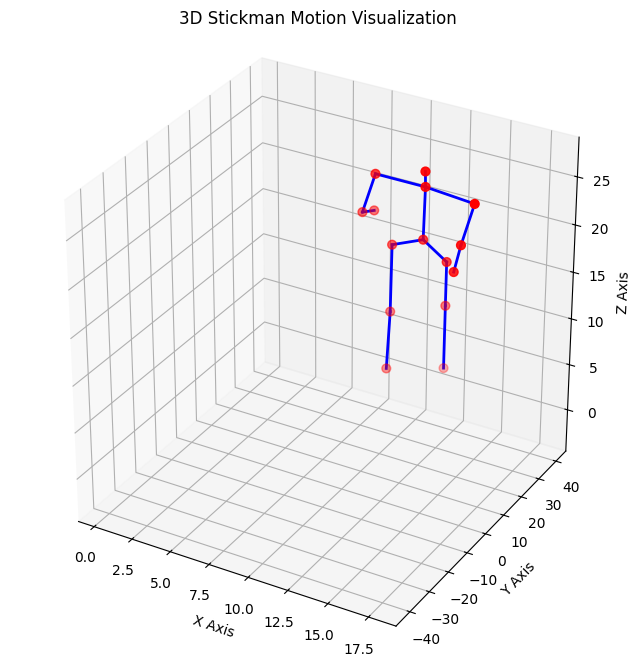

saved: test_gifs/trimmed\walk_walk_008_006.gif  T=283


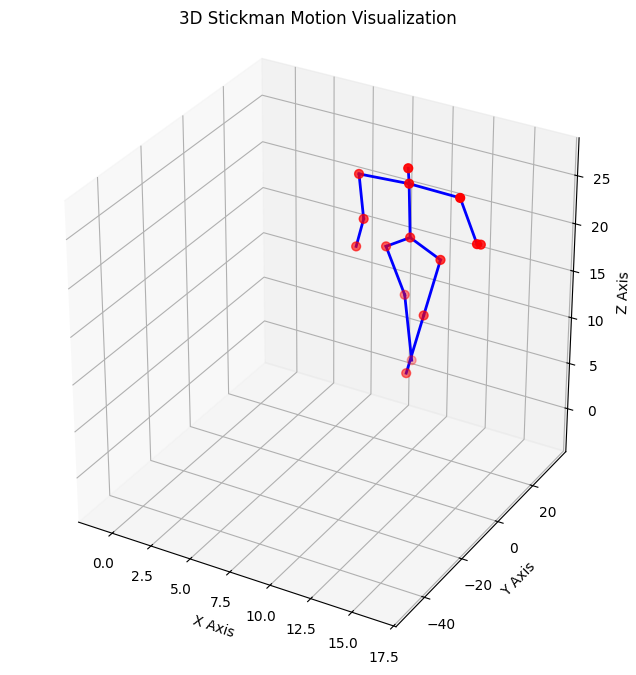

saved: test_gifs/trimmed\walk_walk_008_008.gif  T=283


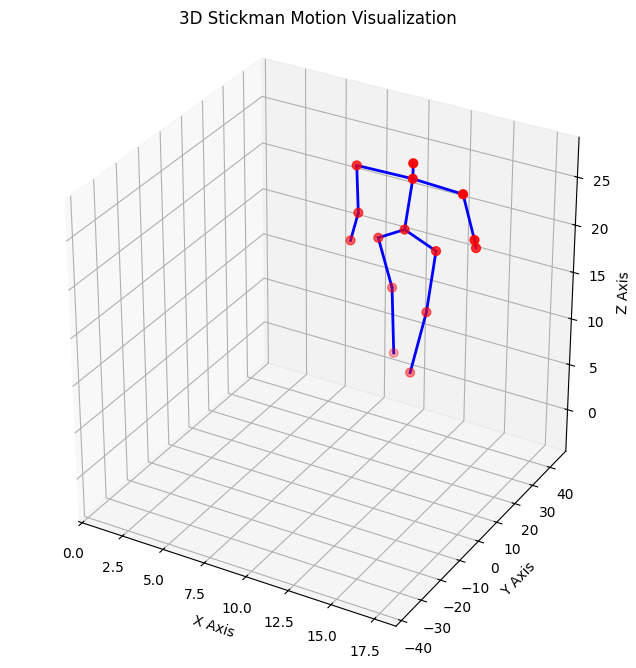

saved: test_gifs/trimmed\walk_walk_008_009.gif  T=293


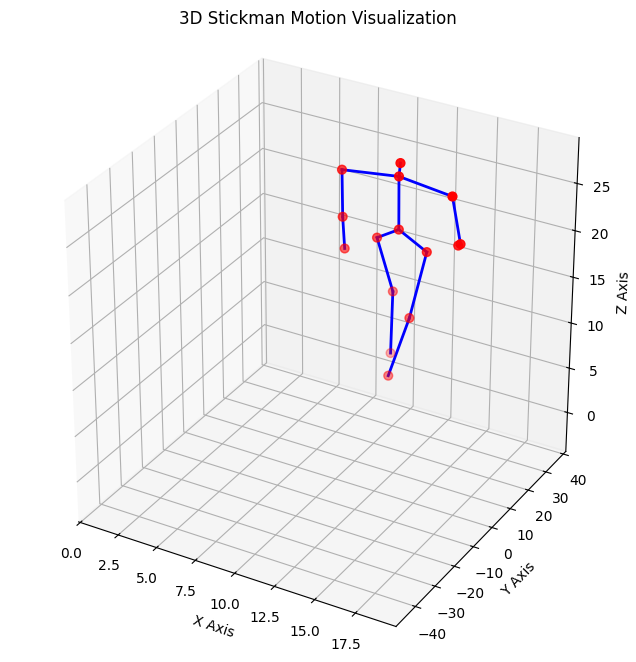

saved: test_gifs/trimmed\walk_walk_002_002.gif  T=294


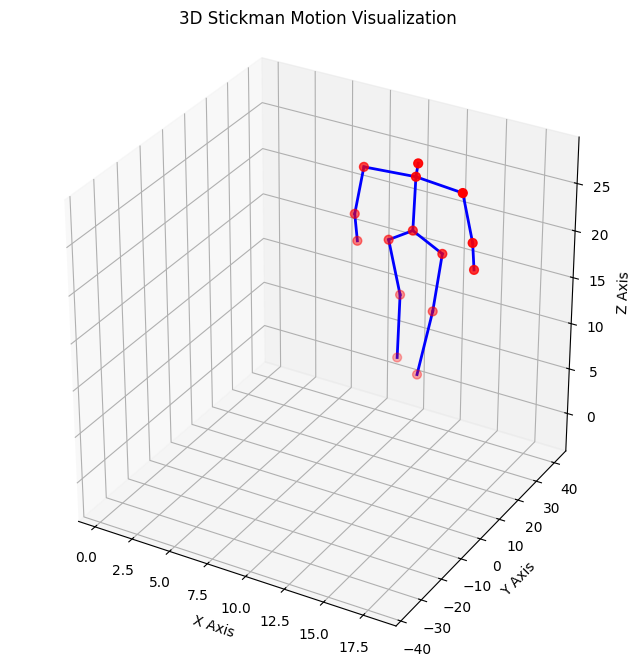

saved: test_gifs/trimmed\walk_walk_007_010.gif  T=301


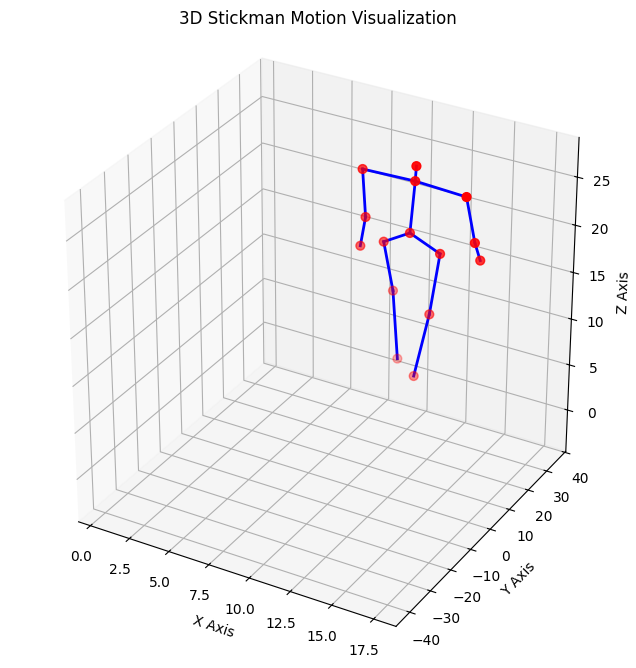

saved: test_gifs/trimmed\walk_walk_008_002.gif  T=305


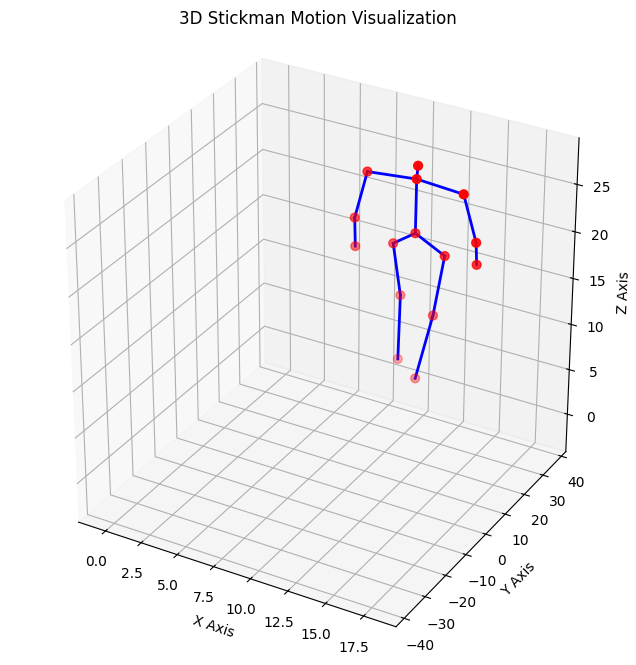

saved: test_gifs/trimmed\walk_walk_007_009.gif  T=306


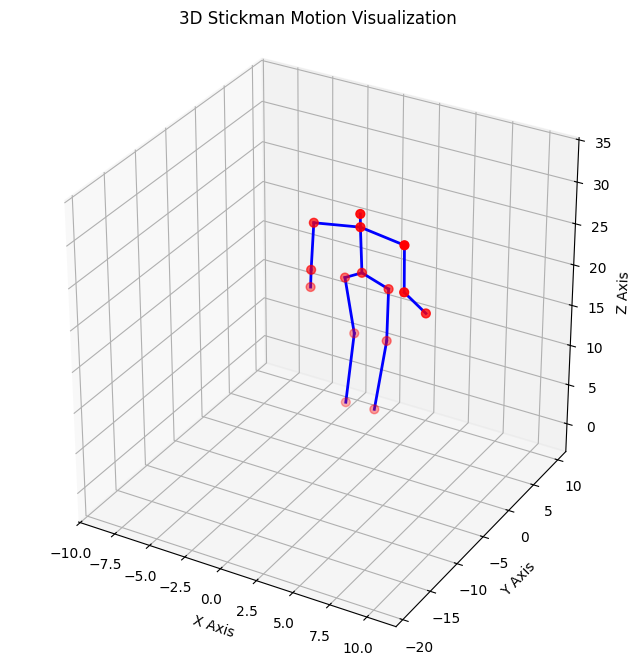

saved: test_gifs/trimmed\jump_forward_jump_016_005.gif  T=257


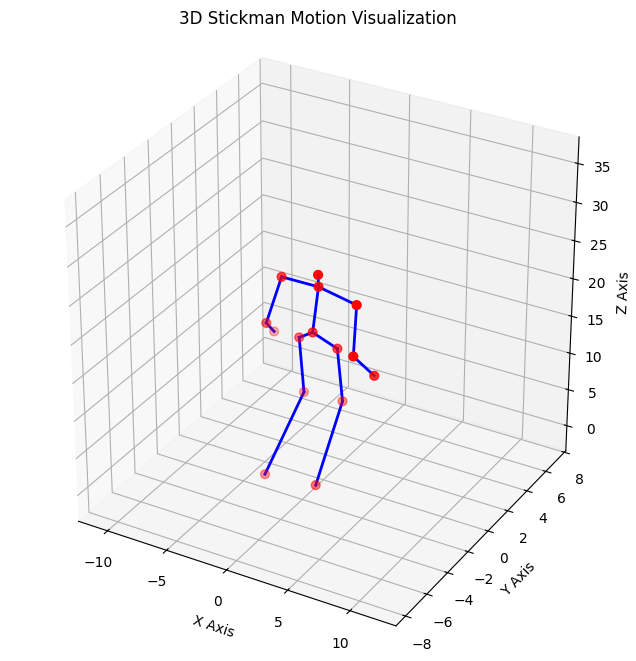

saved: test_gifs/trimmed\jump_jump_013_040.gif  T=290


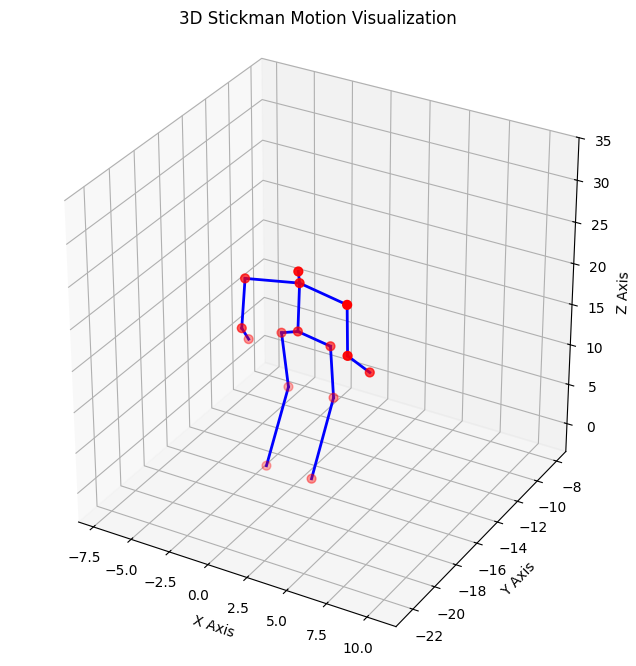

saved: test_gifs/trimmed\jump_jump_016_001.gif  T=317


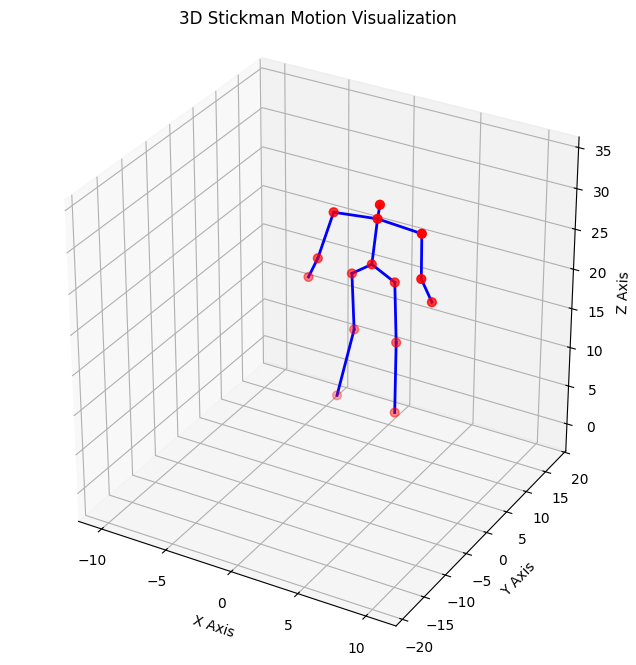

saved: test_gifs/trimmed\jump_forward_jump_013_032.gif  T=319


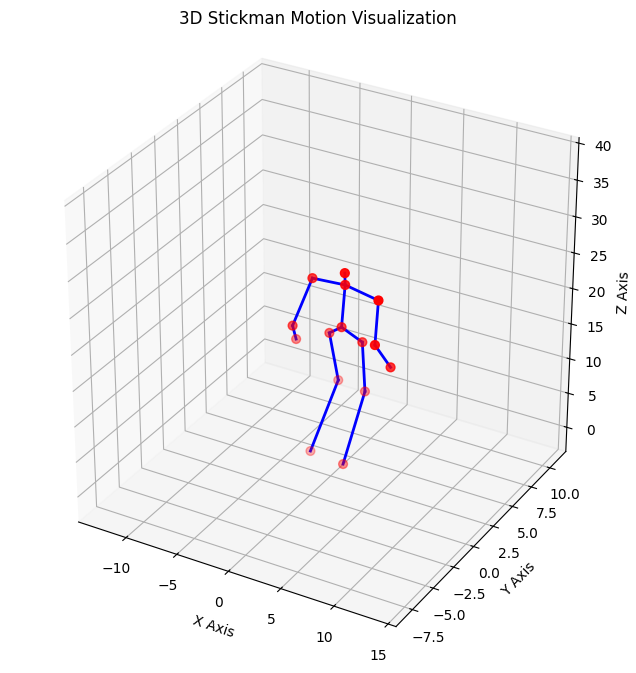

saved: test_gifs/trimmed\jump_jump_013_041.gif  T=319


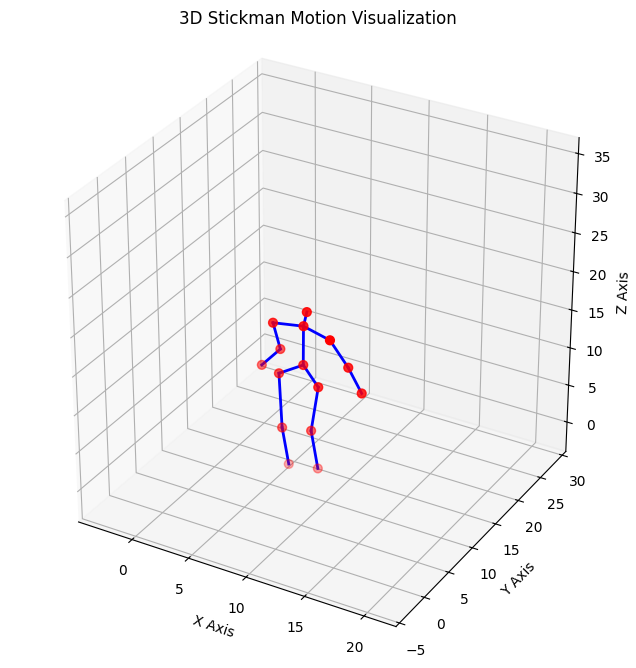

saved: test_gifs/trimmed\jump_jumpforward_091_045.gif  T=322


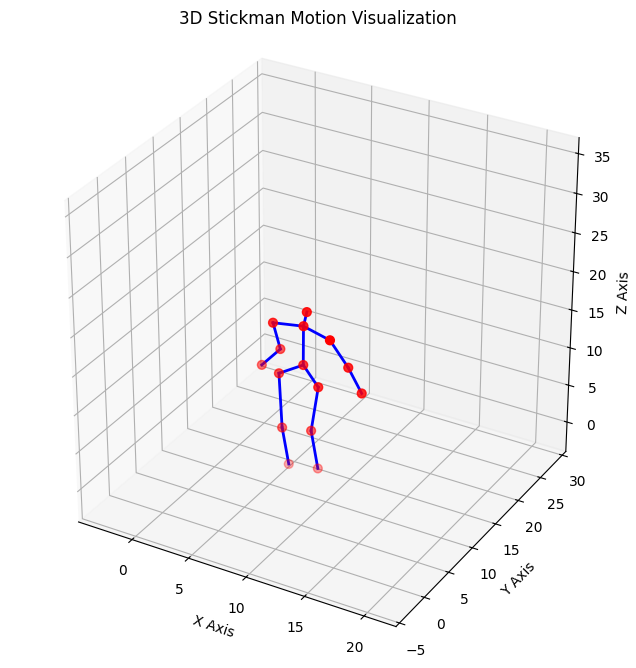

saved: test_gifs/trimmed\jump_jumpforward_105_045.gif  T=322


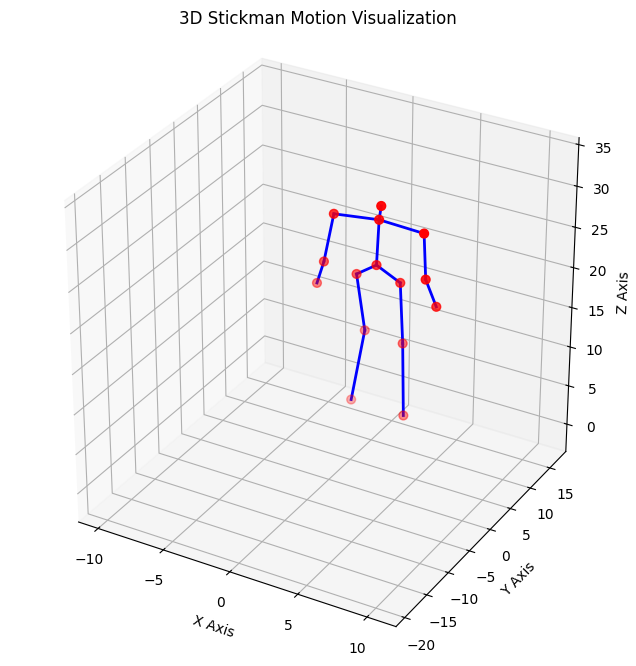

saved: test_gifs/trimmed\jump_forward_jump_013_011.gif  T=333


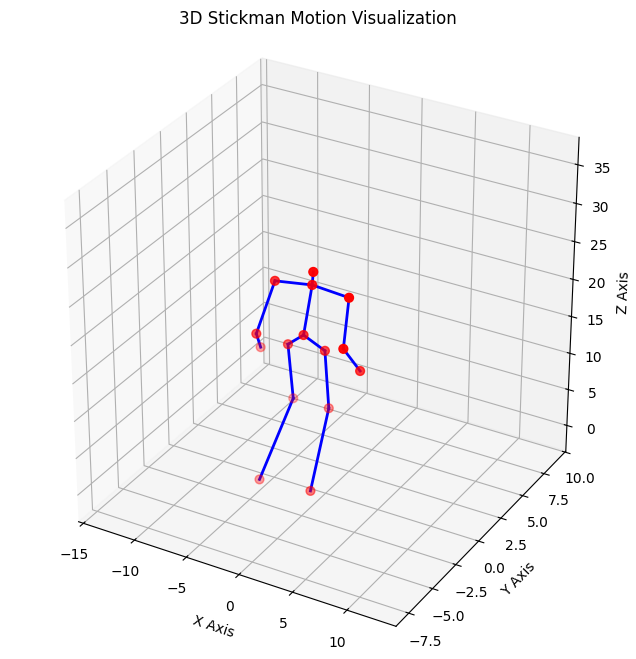

saved: test_gifs/trimmed\jump_jump_013_039.gif  T=351


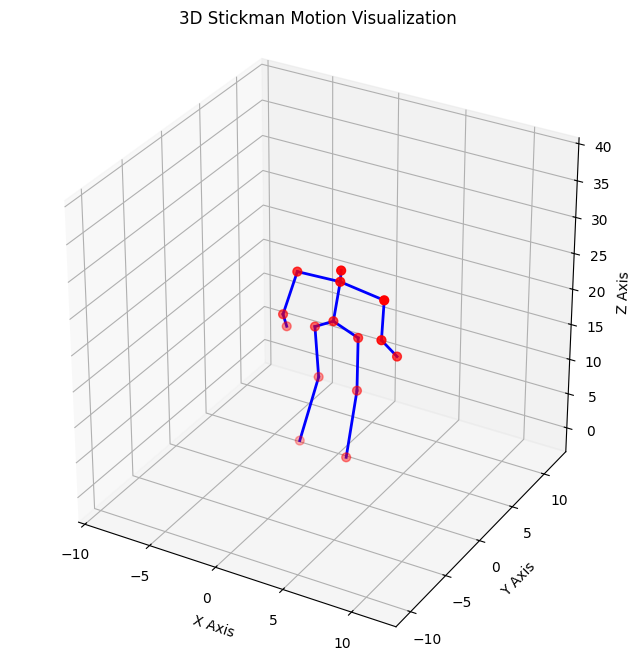

saved: test_gifs/trimmed\jump_jump_013_042.gif  T=355


In [43]:
import os
import numpy as np
import random
import sys
sys.path.append("..")
from utils import animate_skeleton_3d

TRIMMED_ROOT = "trimmed_data"
OUT_DIR = "test_gifs/trimmed"
os.makedirs(OUT_DIR, exist_ok=True)

for label in ["walk", "jump"]:
    folder = os.path.join(TRIMMED_ROOT, label)
    files = [f for f in os.listdir(folder) if f.endswith(".npy")]
    
    # pick 10 with biggest trim ratio
    sizes = []
    for f in files:
        seq = np.load(os.path.join(folder, f))
        sizes.append((f, seq.shape[0]))
    
    # sort by shortest remaining (most trimmed relative to original)
    sizes.sort(key=lambda x: x[1])
    selected = sizes[:10]
    
    for fname, _ in selected:
        seq = np.load(os.path.join(folder, fname))
        out = os.path.join(OUT_DIR, f"{label}_{fname.replace('.npy', '.gif')}")
        animate_skeleton_3d(seq, output_filename=out, fps=24)
        print(f"saved: {out}  T={seq.shape[0]}")

In [4]:
import os
from collections import Counter

for label in ["walk", "jump"]:
    folder = f"trimmed_data/{label}"
    subtypes = []
    for fname in sorted(os.listdir(folder)):
        if fname.endswith(".npy"):
            # extract subtype: everything before last two _XXX_XXX parts
            parts = fname.replace(".npy", "").rsplit("_", 2)
            subtype = parts[0]
            subtypes.append(subtype)
    print(f"\n=== {label.upper()} ===")
    for k, v in sorted(Counter(subtypes).items()):
        print(f"  {k:<35} {v}")


=== WALK ===
  brisk_walk                          1
  normal_walk                         6
  slow_walk                           4
  walk                                94
  walk_forward                        7

=== JUMP ===
  forward_jump                        9
  high_jump                           2
  jump                                36
  jumpforward                         10
  long_jump_forward                   4


In [1]:
from prepare_data import prepare_data
prepare_data()

train: (1260, 48, 15, 3), labels: [623 637]
test: (35, 48, 15, 3), labels: [23 12]


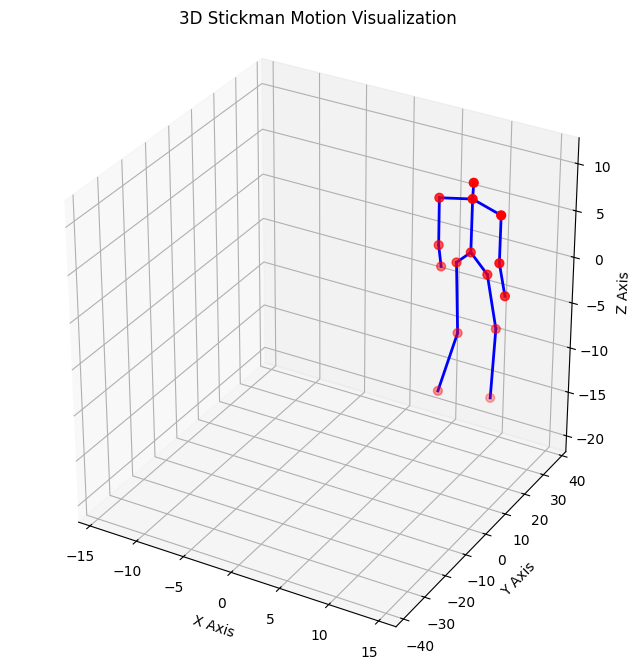

saved: test_gifs/prepared/walk_0.gif


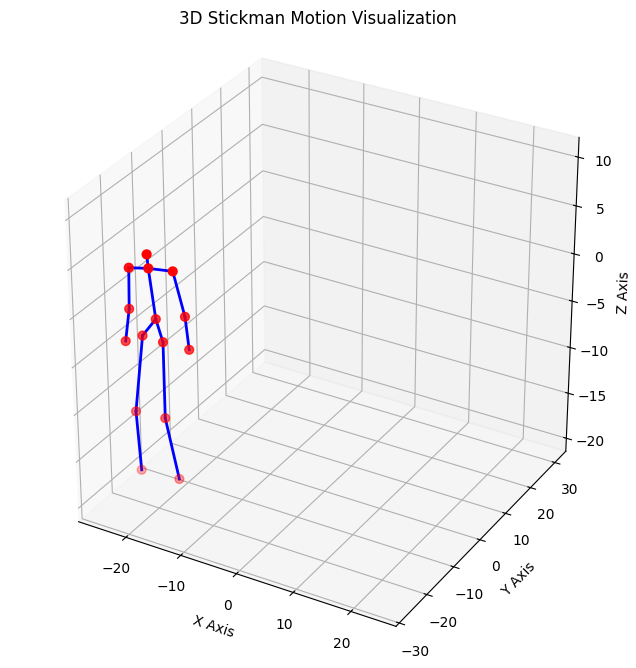

saved: test_gifs/prepared/walk_1.gif


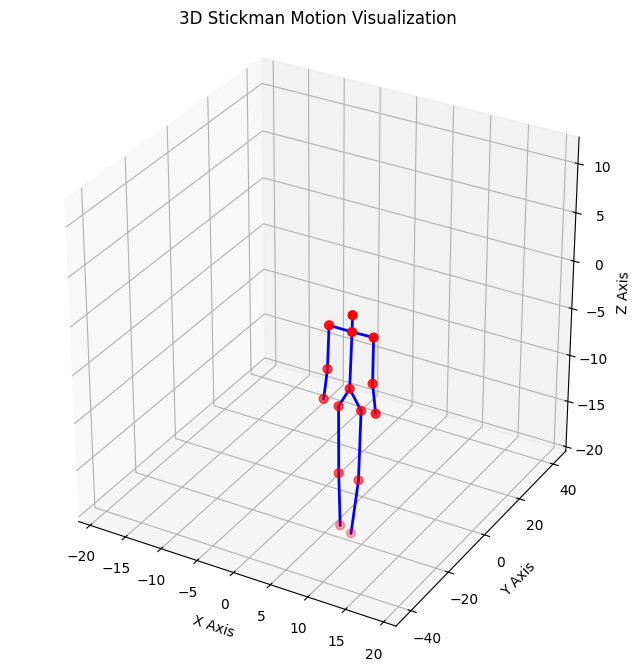

saved: test_gifs/prepared/walk_2.gif


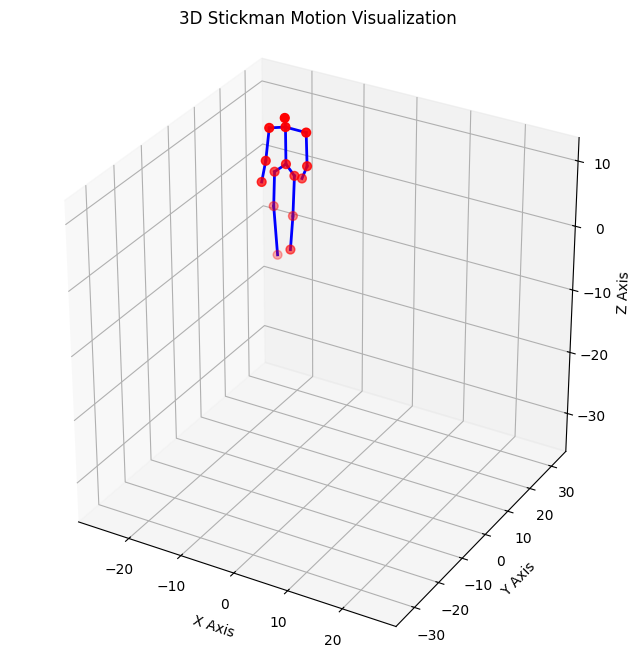

saved: test_gifs/prepared/walk_3.gif


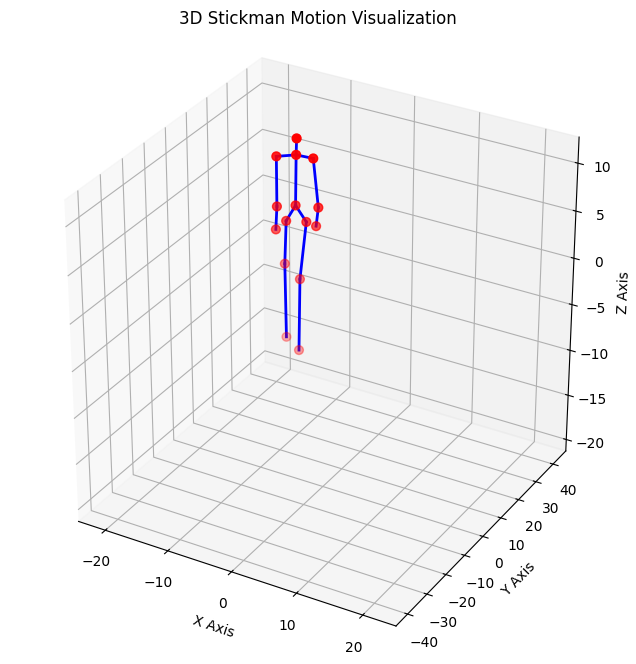

saved: test_gifs/prepared/walk_4.gif


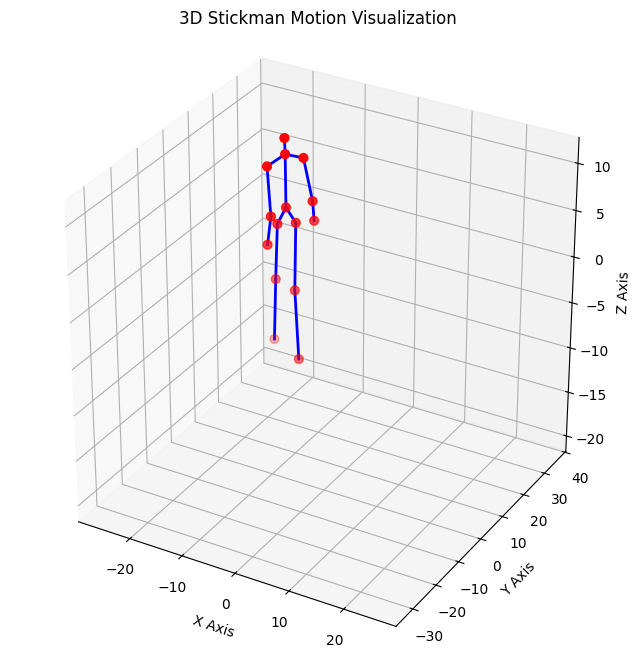

saved: test_gifs/prepared/walk_5.gif


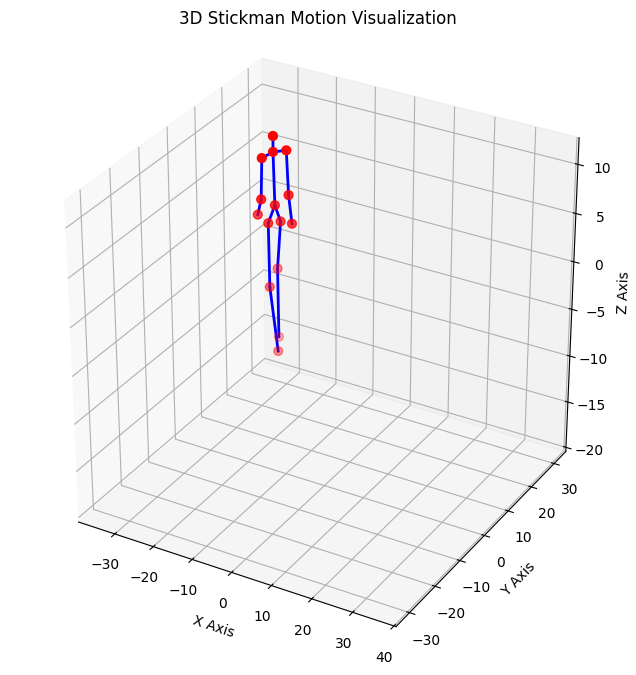

saved: test_gifs/prepared/walk_6.gif


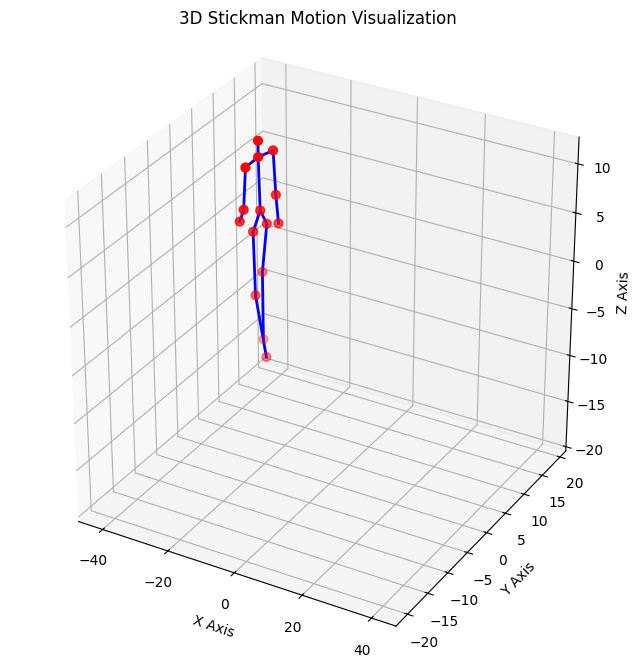

saved: test_gifs/prepared/walk_7.gif


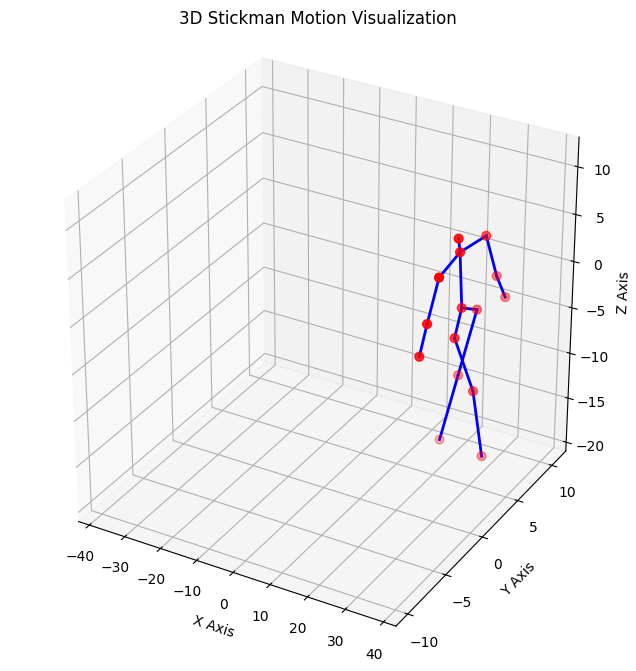

saved: test_gifs/prepared/walk_8.gif


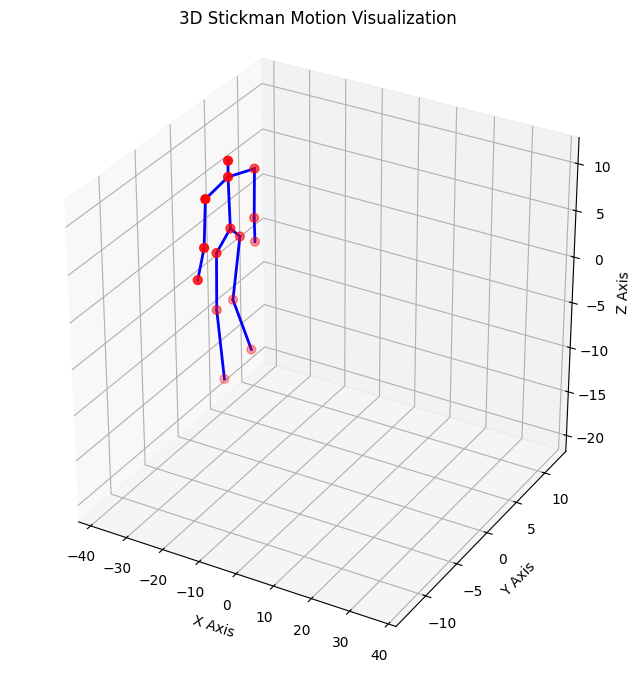

saved: test_gifs/prepared/walk_9.gif


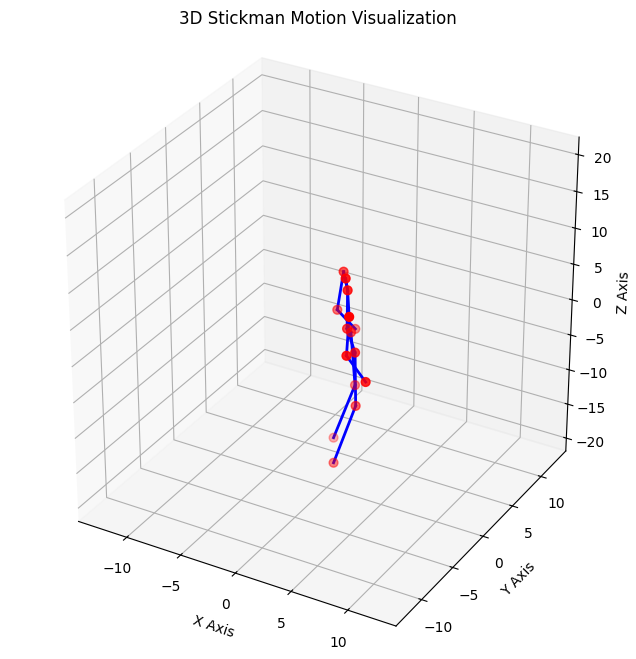

saved: test_gifs/prepared/jump_0.gif


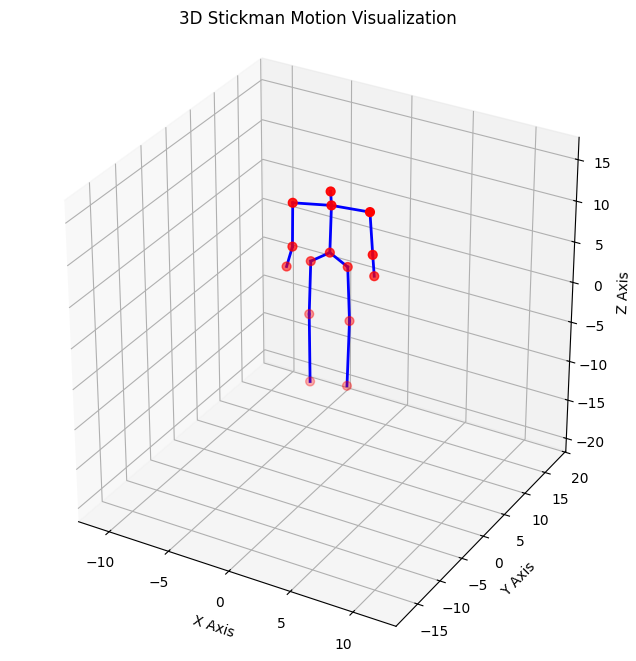

saved: test_gifs/prepared/jump_1.gif


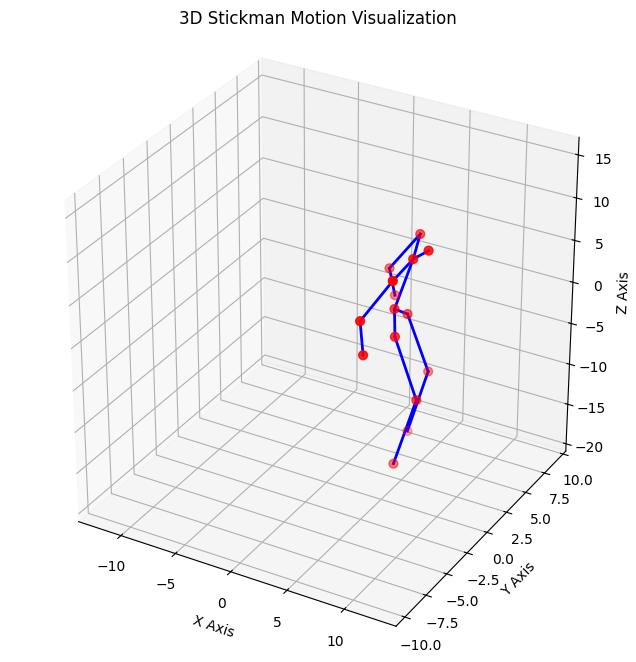

saved: test_gifs/prepared/jump_2.gif


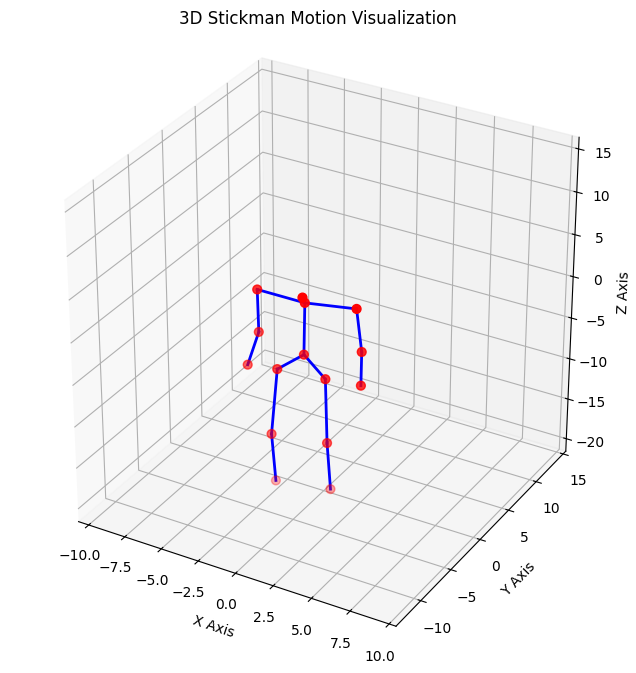

saved: test_gifs/prepared/jump_3.gif


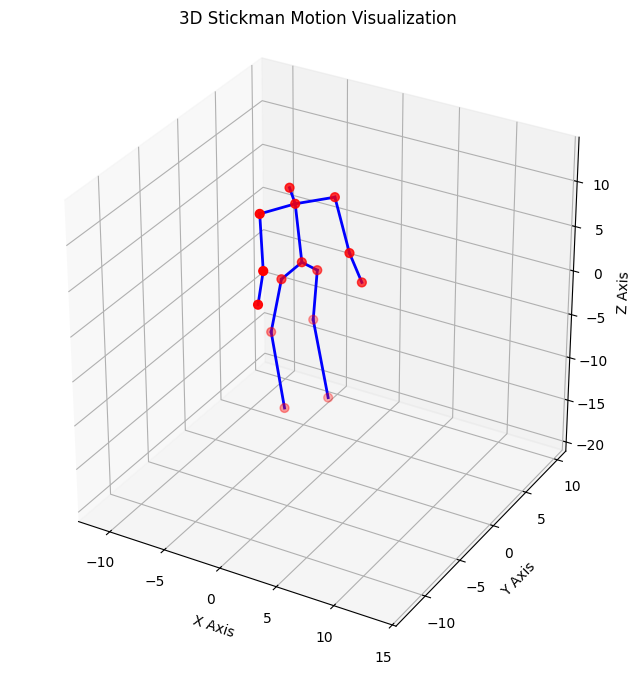

saved: test_gifs/prepared/jump_4.gif


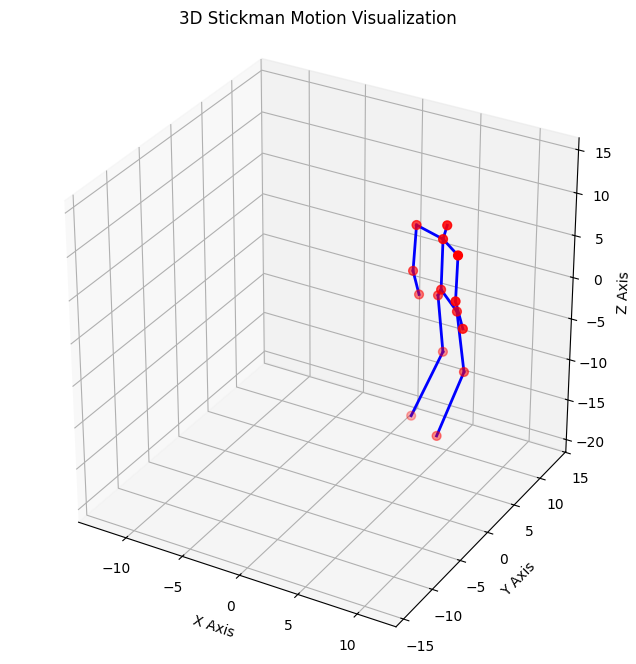

saved: test_gifs/prepared/jump_5.gif


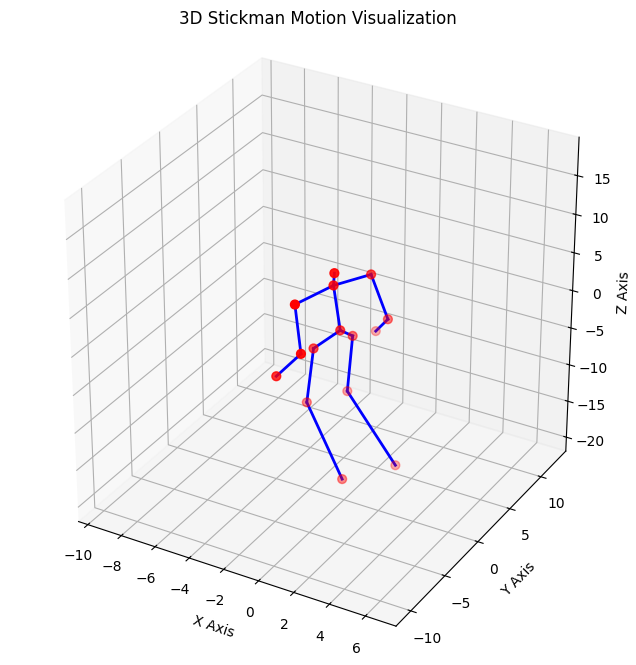

saved: test_gifs/prepared/jump_6.gif


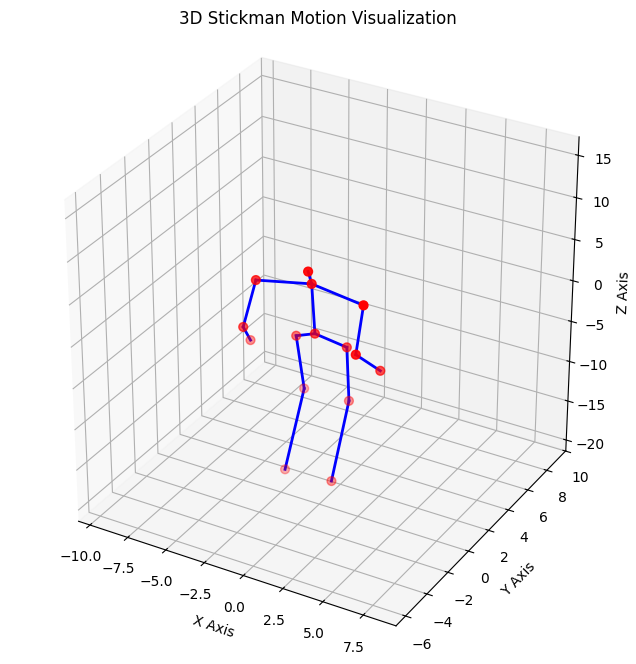

saved: test_gifs/prepared/jump_7.gif


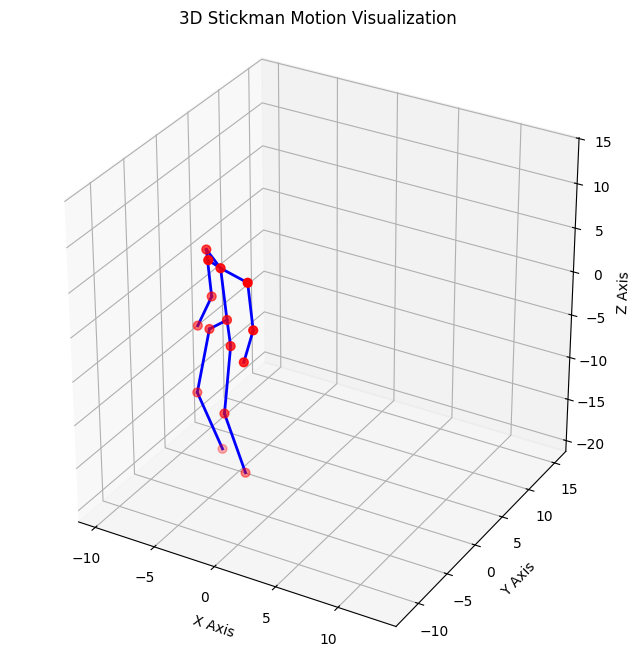

saved: test_gifs/prepared/jump_8.gif


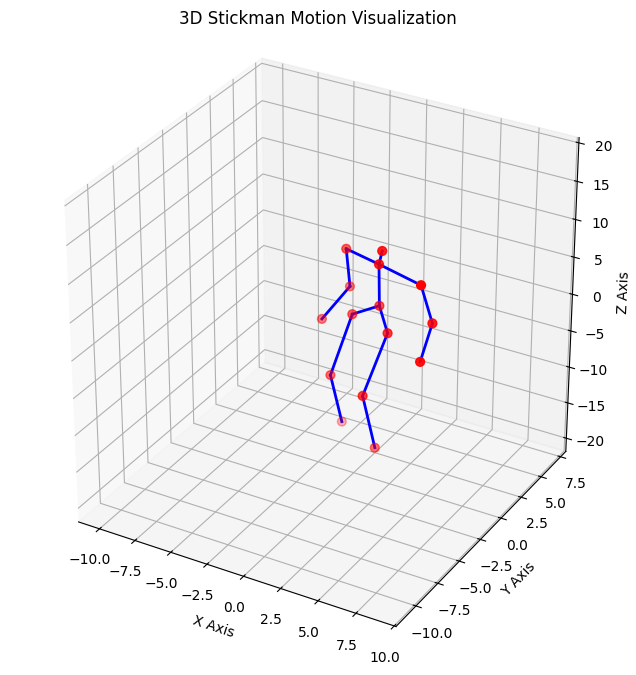

saved: test_gifs/prepared/jump_9.gif


In [3]:
import os
import numpy as np
import random
import sys
sys.path.append("..")
from utils import animate_skeleton_3d

data = np.load("data/train.npz")
sequences = data["sequences"]
labels = data["labels"]

os.makedirs("test_gifs/prepared", exist_ok=True)

for label_idx, label_name in [(0, "walk"), (1, "jump")]:
    indices = np.where(labels == label_idx)[0]
    chosen = random.sample(list(indices), 10)
    for i, idx in enumerate(chosen):
        out = f"test_gifs/prepared/{label_name}_{i}.gif"
        animate_skeleton_3d(sequences[idx], output_filename=out, fps=24)
        print(f"saved: {out}")